# Table of Contents:

## 1. Importing libraries and data
## 2. Data Cleaning and Wrangling
## 3. Creating Random Forests
## 4. Feature Importances
## 5. Top 3 Weather Stations and their Feature Importances

# 1. Importing libraries and data

In [4]:
# Importing libraries and data

import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from numpy import argmax

In [5]:
# Identifying a path to where data is stored

path = 'C:/Users/andyc/Machine Learning - ClimateWins'

In [6]:
# Importing the unscaled Climatewins data set

unscaled = pd.read_csv(os.path.join(path, 'Data Sets', 'Dataset-weather-prediction-dataset-processed.csv'), index_col = False)

In [7]:
# Importing the pleasant_weather data set

pleasant = pd.read_csv(os.path.join(path, 'Data Sets', 'Dataset-Answers-Weather_Prediction_Pleasant_weather.csv'), index_col = False)

In [8]:
unscaled.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,...,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,...,7,0.91,1.0007,0.25,0.84,0,0.7,8.9,5.6,12.1
2,19600103,1,8,2.1,0.90,1.018,0.18,0.30,0,0.0,...,7,0.91,1.0096,0.17,0.08,0,0.1,10.5,8.1,12.9
3,19600104,1,3,2.1,0.92,1.018,0.58,0.00,0,4.1,...,7,0.86,1.0184,0.13,0.98,0,0.0,7.4,7.3,10.6
4,19600105,1,6,2.1,0.95,1.018,0.65,0.14,0,5.4,...,3,0.80,1.0328,0.46,0.00,0,5.7,5.7,3.0,8.4


In [9]:
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
pleasant.shape

(22950, 16)

# 2. Data Cleaning and Wrangling

In [12]:
# Dropping 'Gdansk', 'Roma', and 'Tours' columns from the unscaled dataframe

drop_cols = [col for col in unscaled.columns if col.startswith(('GDANSK', 'ROMA', 'TOURS'))]
unscaled = unscaled.drop(columns=drop_cols)

In [13]:
unscaled.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,...,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,...,7,0.91,1.0007,0.25,0.84,0,0.7,8.9,5.6,12.1
2,19600103,1,8,2.1,0.90,1.018,0.18,0.30,0,0.0,...,7,0.91,1.0096,0.17,0.08,0,0.1,10.5,8.1,12.9
3,19600104,1,3,2.1,0.92,1.018,0.58,0.00,0,4.1,...,7,0.86,1.0184,0.13,0.98,0,0.0,7.4,7.3,10.6
4,19600105,1,6,2.1,0.95,1.018,0.65,0.14,0,5.4,...,3,0.80,1.0328,0.46,0.00,0,5.7,5.7,3.0,8.4


In [14]:
# Finding all the different measurement types for each weather station

# Extracting station names 
stations = set([col.split('_')[0] for col in unscaled.columns])

# Creating a dictionary to store measurement counts for each station
measurement_counts = {location: {} for location in stations}

# Counting occurrences of each measurement type for each station
for col in unscaled.columns:
    parts = col.split('_') 
    location = parts[0] 
    measurement = '_'.join(parts[1:])

    if measurement not in measurement_counts[location]:
        measurement_counts[location][measurement] = 1
    else:
        measurement_counts[location][measurement] += 1

# Printing the measurement counts for each station
for location, measurements in measurement_counts.items():
    print(f"Location: {location}")
    for measurement, count in measurements.items():
        print(f"  - {measurement}: {count}")
    print()

Location: DUSSELDORF
  - cloud_cover: 1
  - wind_speed: 1
  - humidity: 1
  - pressure: 1
  - global_radiation: 1
  - precipitation: 1
  - snow_depth: 1
  - sunshine: 1
  - temp_mean: 1
  - temp_min: 1
  - temp_max: 1

Location: DEBILT
  - cloud_cover: 1
  - wind_speed: 1
  - humidity: 1
  - pressure: 1
  - global_radiation: 1
  - precipitation: 1
  - sunshine: 1
  - temp_mean: 1
  - temp_min: 1
  - temp_max: 1

Location: HEATHROW
  - cloud_cover: 1
  - humidity: 1
  - pressure: 1
  - global_radiation: 1
  - precipitation: 1
  - snow_depth: 1
  - sunshine: 1
  - temp_mean: 1
  - temp_min: 1
  - temp_max: 1

Location: MONTH
  - : 1

Location: MUNCHENB
  - cloud_cover: 1
  - humidity: 1
  - global_radiation: 1
  - precipitation: 1
  - snow_depth: 1
  - sunshine: 1
  - temp_mean: 1
  - temp_min: 1
  - temp_max: 1

Location: SONNBLICK
  - cloud_cover: 1
  - wind_speed: 1
  - humidity: 1
  - pressure: 1
  - global_radiation: 1
  - precipitation: 1
  - sunshine: 1
  - temp_mean: 1
  - temp_m

In [15]:
# Dropping columns for 'wind_speed' and 'snow_depth'

drop_cols = [col for col in unscaled.columns if col.endswith(('wind_speed', 'snow_depth'))]

unscaled = unscaled.drop(columns=drop_cols)

In [16]:
unscaled.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [17]:
# There is missing data for Kassel's cloud cover, Stockholm's humidity, and Munchenb's pressure

# Defining relationships between stations
# Using similar stations to fill in missing data
location_pairs = {
    'KASSEL': 'LJUBLJANA',
    'STOCKHOLM': 'OSLO',
    'MUNCHENB': 'SONNBLICK'
}

# Defining the desired order of measurements
measurement_order = ['cloud_cover', 'humidity', 'pressure', 'global_radiation', 
                     'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max']

# Function to fill in missing values and inserting it in the proper position
def fill_missing_values(unscaled, location, measurement, neighbor):
    """
    Fills missing values for a given location and measurement using data from a neighbor location.
    Inserts the new column in the correct position based on the measurement order.

    Args:
        df_unscaled: The DataFrame containing the weather data.
        location: The location with missing values.
        measurement: The measurement with missing values.
        neighbor: The neighboring location to use for filling.

    Returns:
        The updated DataFrame with filled missing values and columns in the correct order.
    """
    source_col = f'{neighbor}_{measurement}'
    target_col = f'{location}_{measurement}'

    # Determining the insertion index 
    if measurement == measurement_order[0]:
        location_columns = [col for col in unscaled.columns if col.startswith(location)]
        if location_columns:
            insert_index = unscaled.columns.get_loc(location_columns[0]) 
        else:
            insert_index = 0
    else:
        insert_index = unscaled.columns.get_loc(f'{location}_{measurement_order[measurement_order.index(measurement) - 1]}') + 1 

    # Creating the new column with missing values and inserting it in the proper position
    unscaled.insert(insert_index, target_col, np.nan) 

    # Filling in the missing values in the new column
    unscaled[target_col].fillna(unscaled[source_col], inplace=True) 

    return unscaled

# Filling in the missing values for each location and measurement
for location, neighbor in location_pairs.items():
    for measurement in measurement_order:
        if f'{location}_{measurement}' not in unscaled.columns:
            unscaled = fill_missing_values(unscaled, location, measurement, neighbor)

# Checking the new columns for existence and location
added_columns = [col for col in unscaled.columns if col.startswith(('KASSEL', 'STOCKHOLM', 'MUNCHENB'))]
print(unscaled[added_columns])

       KASSEL_cloud_cover  KASSEL_humidity  KASSEL_pressure  \
0                     8.0             0.82           1.0094   
1                     6.0             0.86           1.0086   
2                     8.0             0.91           1.0129   
3                     6.0             0.87           1.0290   
4                     7.0             0.86           1.0262   
...                   ...              ...              ...   
22945                 4.0             0.77           1.0161   
22946                 3.0             0.77           1.0161   
22947                 3.0             0.77           1.0161   
22948                 3.0             0.77           1.0161   
22949                 3.0             0.77           1.0161   

       KASSEL_global_radiation  KASSEL_precipitation  KASSEL_sunshine  \
0                         0.28                  0.48              1.6   
1                         0.12                  0.27              0.0   
2                       

C:\Users\andyc\AppData\Local\Temp\ipykernel_7080\4151646558.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  unscaled[target_col].fillna(unscaled[source_col], inplace=True)
C:\Users\andyc\AppData\Local\Temp\ipykernel_7080\4151646558.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [18]:
unscaled.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min',
       ...
       'STOCKHOLM_temp_max', 'VALENTIA_cloud_cover', 'VALENTIA_humidity',
       'VALENTIA_pressure', 'VALENTIA_global_radiation',
       'VALENTIA_precipitation', 'VALENTIA_sunshine', 'VALENTIA_temp_mean',
       'VALENTIA_temp_min', 'VALENTIA_temp_max'],
      dtype='object', length=137)

In [19]:
# Exporting the cleaned unscaled weather data
unscaled.to_csv(os.path.join(path, 'Data Sets', 'cleaned_weather.csv'), index=False)

### 2010

In [21]:
# Filtering the cleaned weather dataset to the 2010s

unscaled_2010 = unscaled[unscaled['DATE'].astype(str).str.startswith('201')] 

unscaled_2010.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,20100101,1,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,...,-7.0,1,0.80,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0
18264,20100102,1,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,...,-7.1,1,0.82,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2
18265,20100103,1,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,...,-7.1,4,0.71,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1
18266,20100104,1,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,...,-3.6,2,0.67,1.0219,0.48,0.51,6.5,3.7,1.3,3.8
18267,20100105,1,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,...,-5.5,4,0.78,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4


In [22]:
unscaled_2010.shape

(3652, 137)

In [23]:
# Filtering the pleasant dataset to the 2010s

pleasant_2010 = pleasant[pleasant['DATE'].astype(str).str.startswith('201')] 

pleasant_2010.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [24]:
pleasant_2010.shape

(3652, 16)

In [25]:
# Dropping the 'DATE' and 'MONTH' columns from unscaled_2010 dataset

cleaned_2010 = unscaled_2010.drop(columns=['DATE', 'MONTH'])

In [26]:
cleaned_2010.shape

(3652, 135)

In [27]:
# Dropping the 'DATE' column from the pleasant_2010 dataset

cleaned_pleasant_2010 = pleasant_2010.drop(columns=['DATE'])

In [28]:
cleaned_pleasant_2010.shape

(3652, 15)

In [29]:
# Creating matrices by combining 15 columns in pleasant weather data into single column

y_1 = cleaned_pleasant_2010.max(axis=1)

print("Shape of y_1_combined:", y_1.shape)

Shape of y_1_combined: (3652,)


In [30]:
# Checking unique values in y_combined

print("Unique values in y_1_combined:", y_1.unique())

Unique values in y_1_combined: [0 1]


In [31]:
# checking to see that y has the correct shape

y_1 = y_1.to_numpy().reshape(-1)

In [32]:
y_1.shape

(3652,)

In [33]:
# Creating the X matrix

X_1 = cleaned_2010.to_numpy()

In [34]:
# Checking both X and y shapes

print(X_1.shape)
print(y_1.shape)

(3652, 135)
(3652,)


In [35]:
# Splitting the data into training and testing sets

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, random_state=42)

In [36]:
# Checking both shapes

print(X_train_1.shape, y_train_1.shape)
print(X_test_1.shape, y_test_1.shape)

(2739, 135) (2739,)
(913, 135) (913,)


### 2000

In [38]:
# Filtering the cleaned weather dataset to the 2010s

unscaled_2000 = unscaled[unscaled['DATE'].astype(str).str.startswith('200')] 

unscaled_2000.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
14610,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,0.7,6,0.89,1.0235,0.22,0.10,0.7,6.6,2.1,11.0
14611,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,2.0,8,0.92,1.0177,0.13,0.42,0.0,9.6,7.3,10.6
14612,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,2.8,4,0.79,1.0154,0.22,1.05,1.2,8.6,7.3,9.9
14613,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,4.6,6,0.76,1.0099,0.36,0.34,3.5,8.1,5.0,7.7
14614,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,2.9,7,0.81,0.9957,0.12,0.33,0.0,7.7,4.0,11.3


In [39]:
unscaled_2000.shape

(3653, 137)

In [40]:
# Filtering the pleasant dataset to the 2000s

pleasant_2000 = pleasant[pleasant['DATE'].astype(str).str.startswith('200')] 

pleasant_2000.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
14610,20000101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14611,20000102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14612,20000103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14613,20000104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14614,20000105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [41]:
pleasant_2000.shape

(3653, 16)

In [42]:
# Dropping the 'DATE' and 'MONTH' columns from the unscaled_2000 dataset

cleaned_2000 = unscaled_2000.drop(columns=['DATE', 'MONTH'])

In [43]:
cleaned_2000.shape

(3653, 135)

In [44]:
# Dropping the 'DATE' column from the pleasant_2000 dataset

cleaned_pleasant_2000 = pleasant_2000.drop(columns=['DATE'])

In [45]:
cleaned_pleasant_2000.shape

(3653, 15)

In [46]:
# Create matrices by combining 15 columns in pleasant weather data into single column

y_2 = cleaned_pleasant_2000.max(axis=1)

print("Shape of y_2_combined:", y_2.shape)

Shape of y_2_combined: (3653,)


In [47]:
# Checking the unique values in y_combined

print("Unique values in y_2_combined:", y_2.unique())

Unique values in y_2_combined: [0 1]


In [48]:
# Checking to see if y has the correct shape

y_2 = y_2.to_numpy().reshape(-1)

In [49]:
y_2.shape

(3653,)

In [50]:
# Creating the X matrix

X_2 = cleaned_2000.to_numpy()

In [51]:
# Checking both shapes

print(X_2.shape)
print(y_2.shape)

(3653, 135)
(3653,)


In [52]:
# Splitting the data into training and testing sets

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, random_state=42)

In [53]:
# Checking both shapes

print(X_train_2.shape, y_train_2.shape)
print(X_test_2.shape, y_test_2.shape)

(2739, 135) (2739,)
(914, 135) (914,)


# 3. Creating Random Forests

##### 2010s Data

In [56]:
# Creating a Random Forest classifier

clf_1 = RandomForestClassifier(n_estimators = 100, max_depth=10)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters

clf_1.fit(X_train_1, y_train_1)

RandomForestClassifier(max_depth=10)

In [57]:
# Performing predictions on the test dataset

y_pred_1 = clf_1.predict(X_test_1)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test_1, y_pred_1))

Model Accuracy:  0.9627601314348302


In [58]:
# Checking the unique values in y

unique_classes = np.unique(y_1)

print(unique_classes)

print(len(unique_classes)) 

[0 1]
2


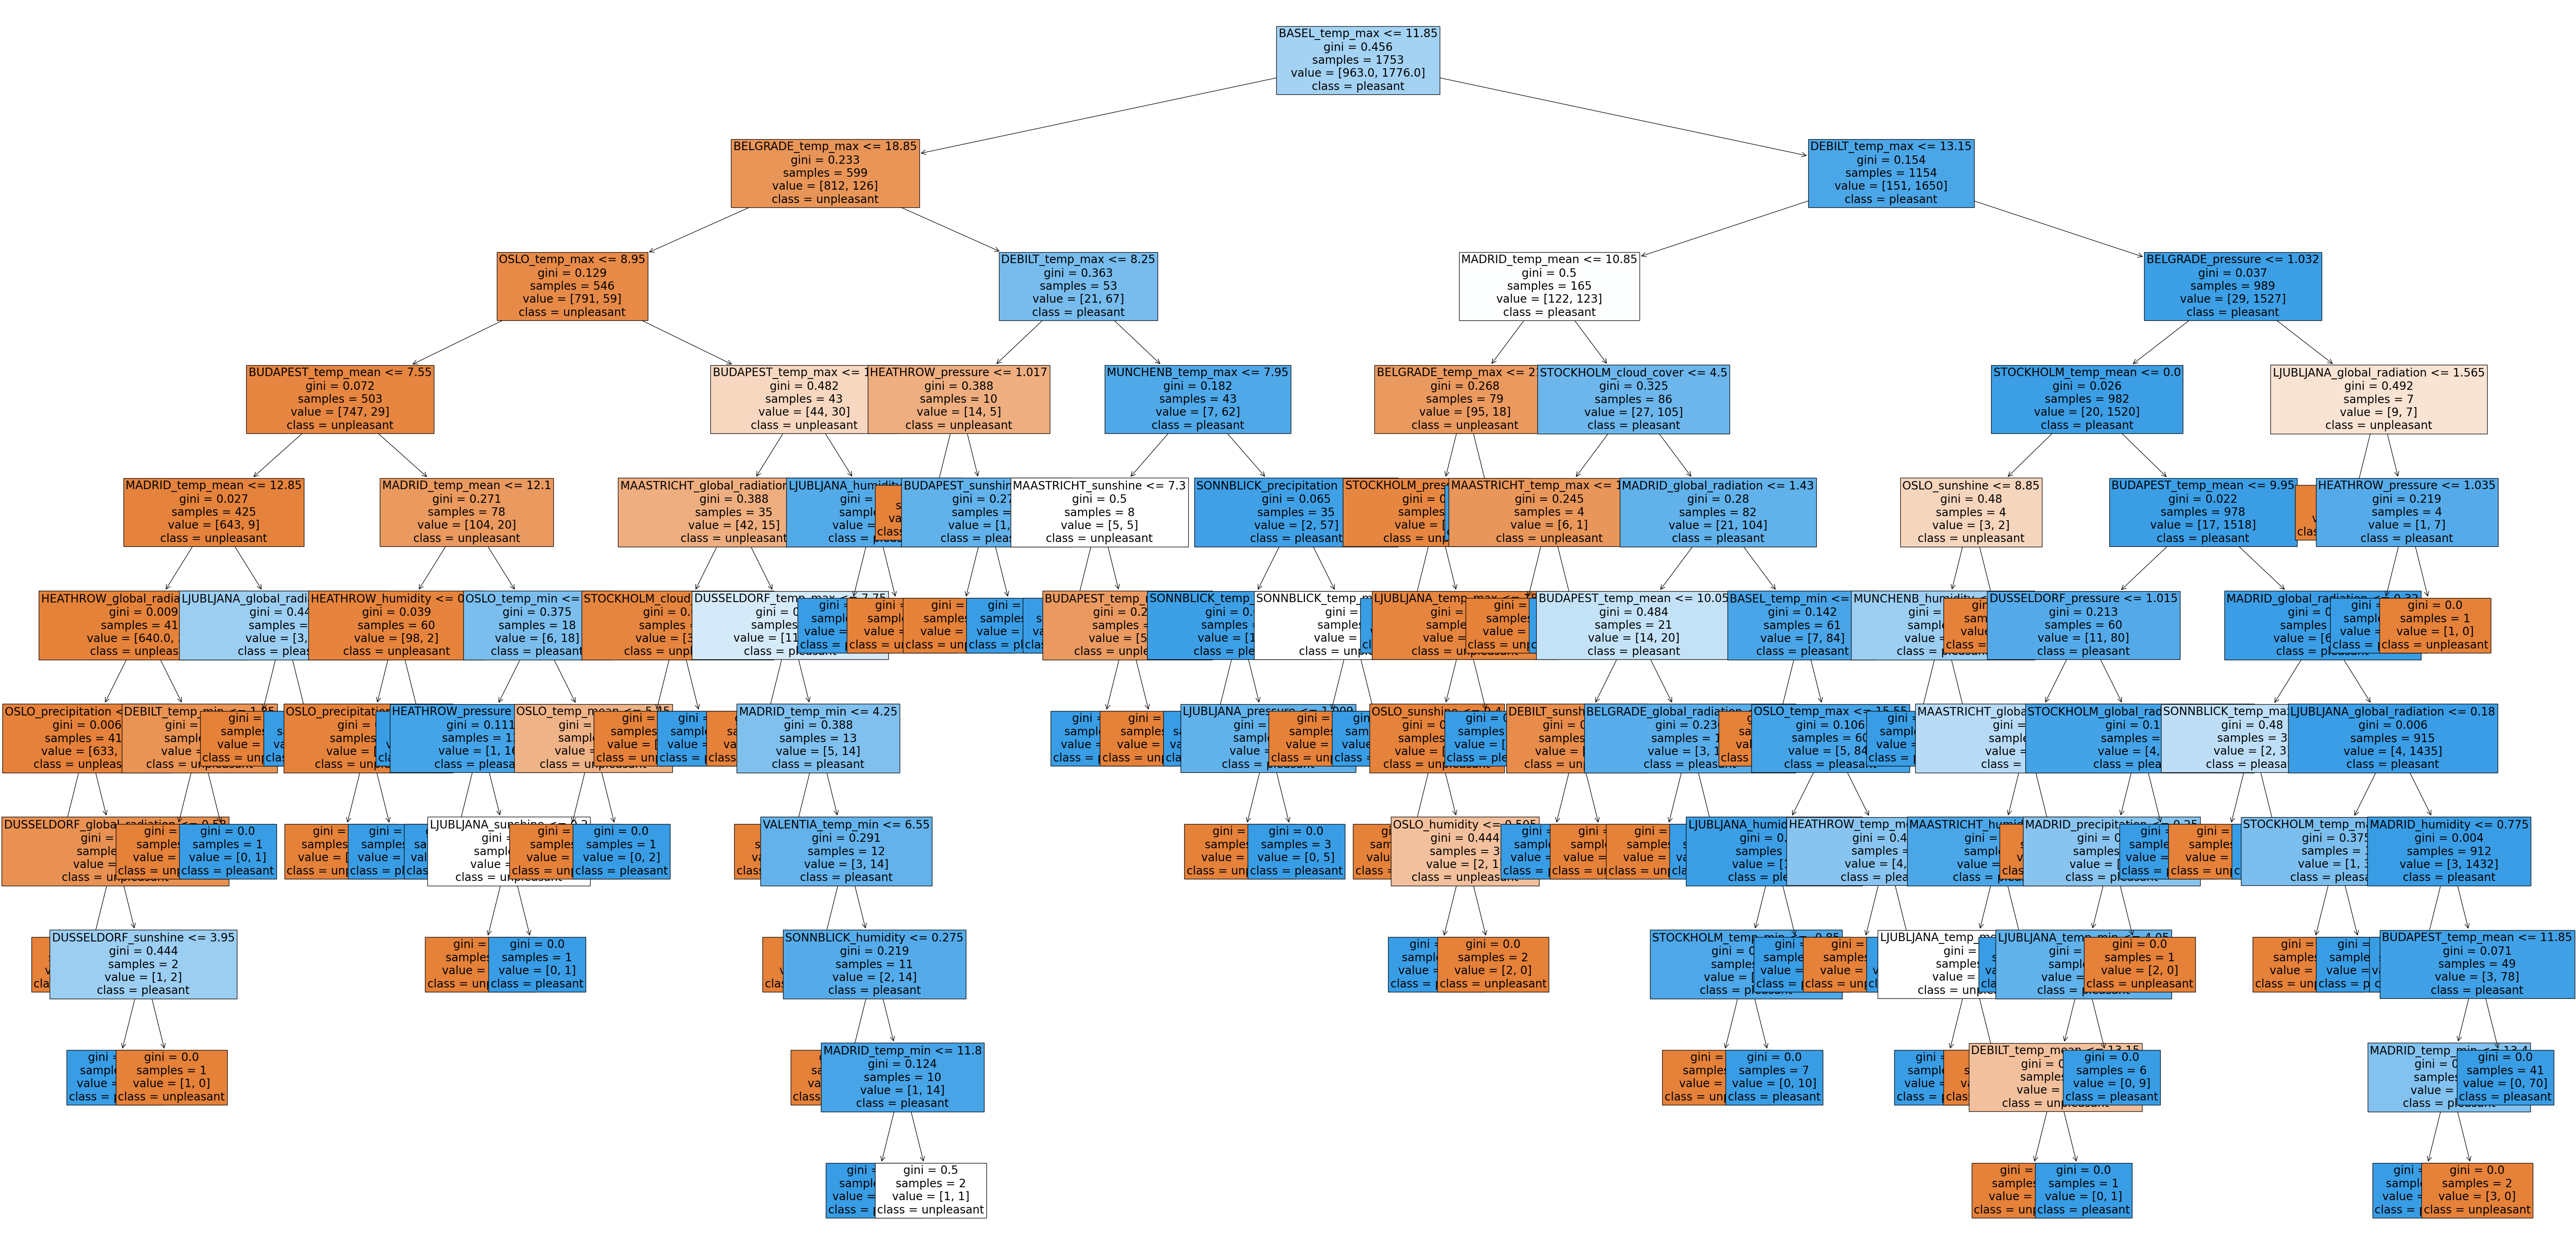

In [59]:
# Plotting the random forest for the 2010s

rf_1 = plt.figure(figsize=(80,40))
plot_tree(clf_1.estimators_[5], fontsize = 20, feature_names=cleaned_2010.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

In [60]:
rf_1.savefig(os.path.join(path, 'Visualizations', 'random_forest_2010s.png'),bbox_inches='tight')

##### 2000s Data

In [62]:
# Creating a Random Forest classifier

clf_2 = RandomForestClassifier(n_estimators = 100, max_depth=10)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters

clf_2.fit(X_train_2, y_train_2)

RandomForestClassifier(max_depth=10)

In [63]:
# Perform the predictions on the test dataset

y_pred_2 = clf_2.predict(X_test_2)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test_2, y_pred_2))

Model Accuracy:  0.9507658643326039


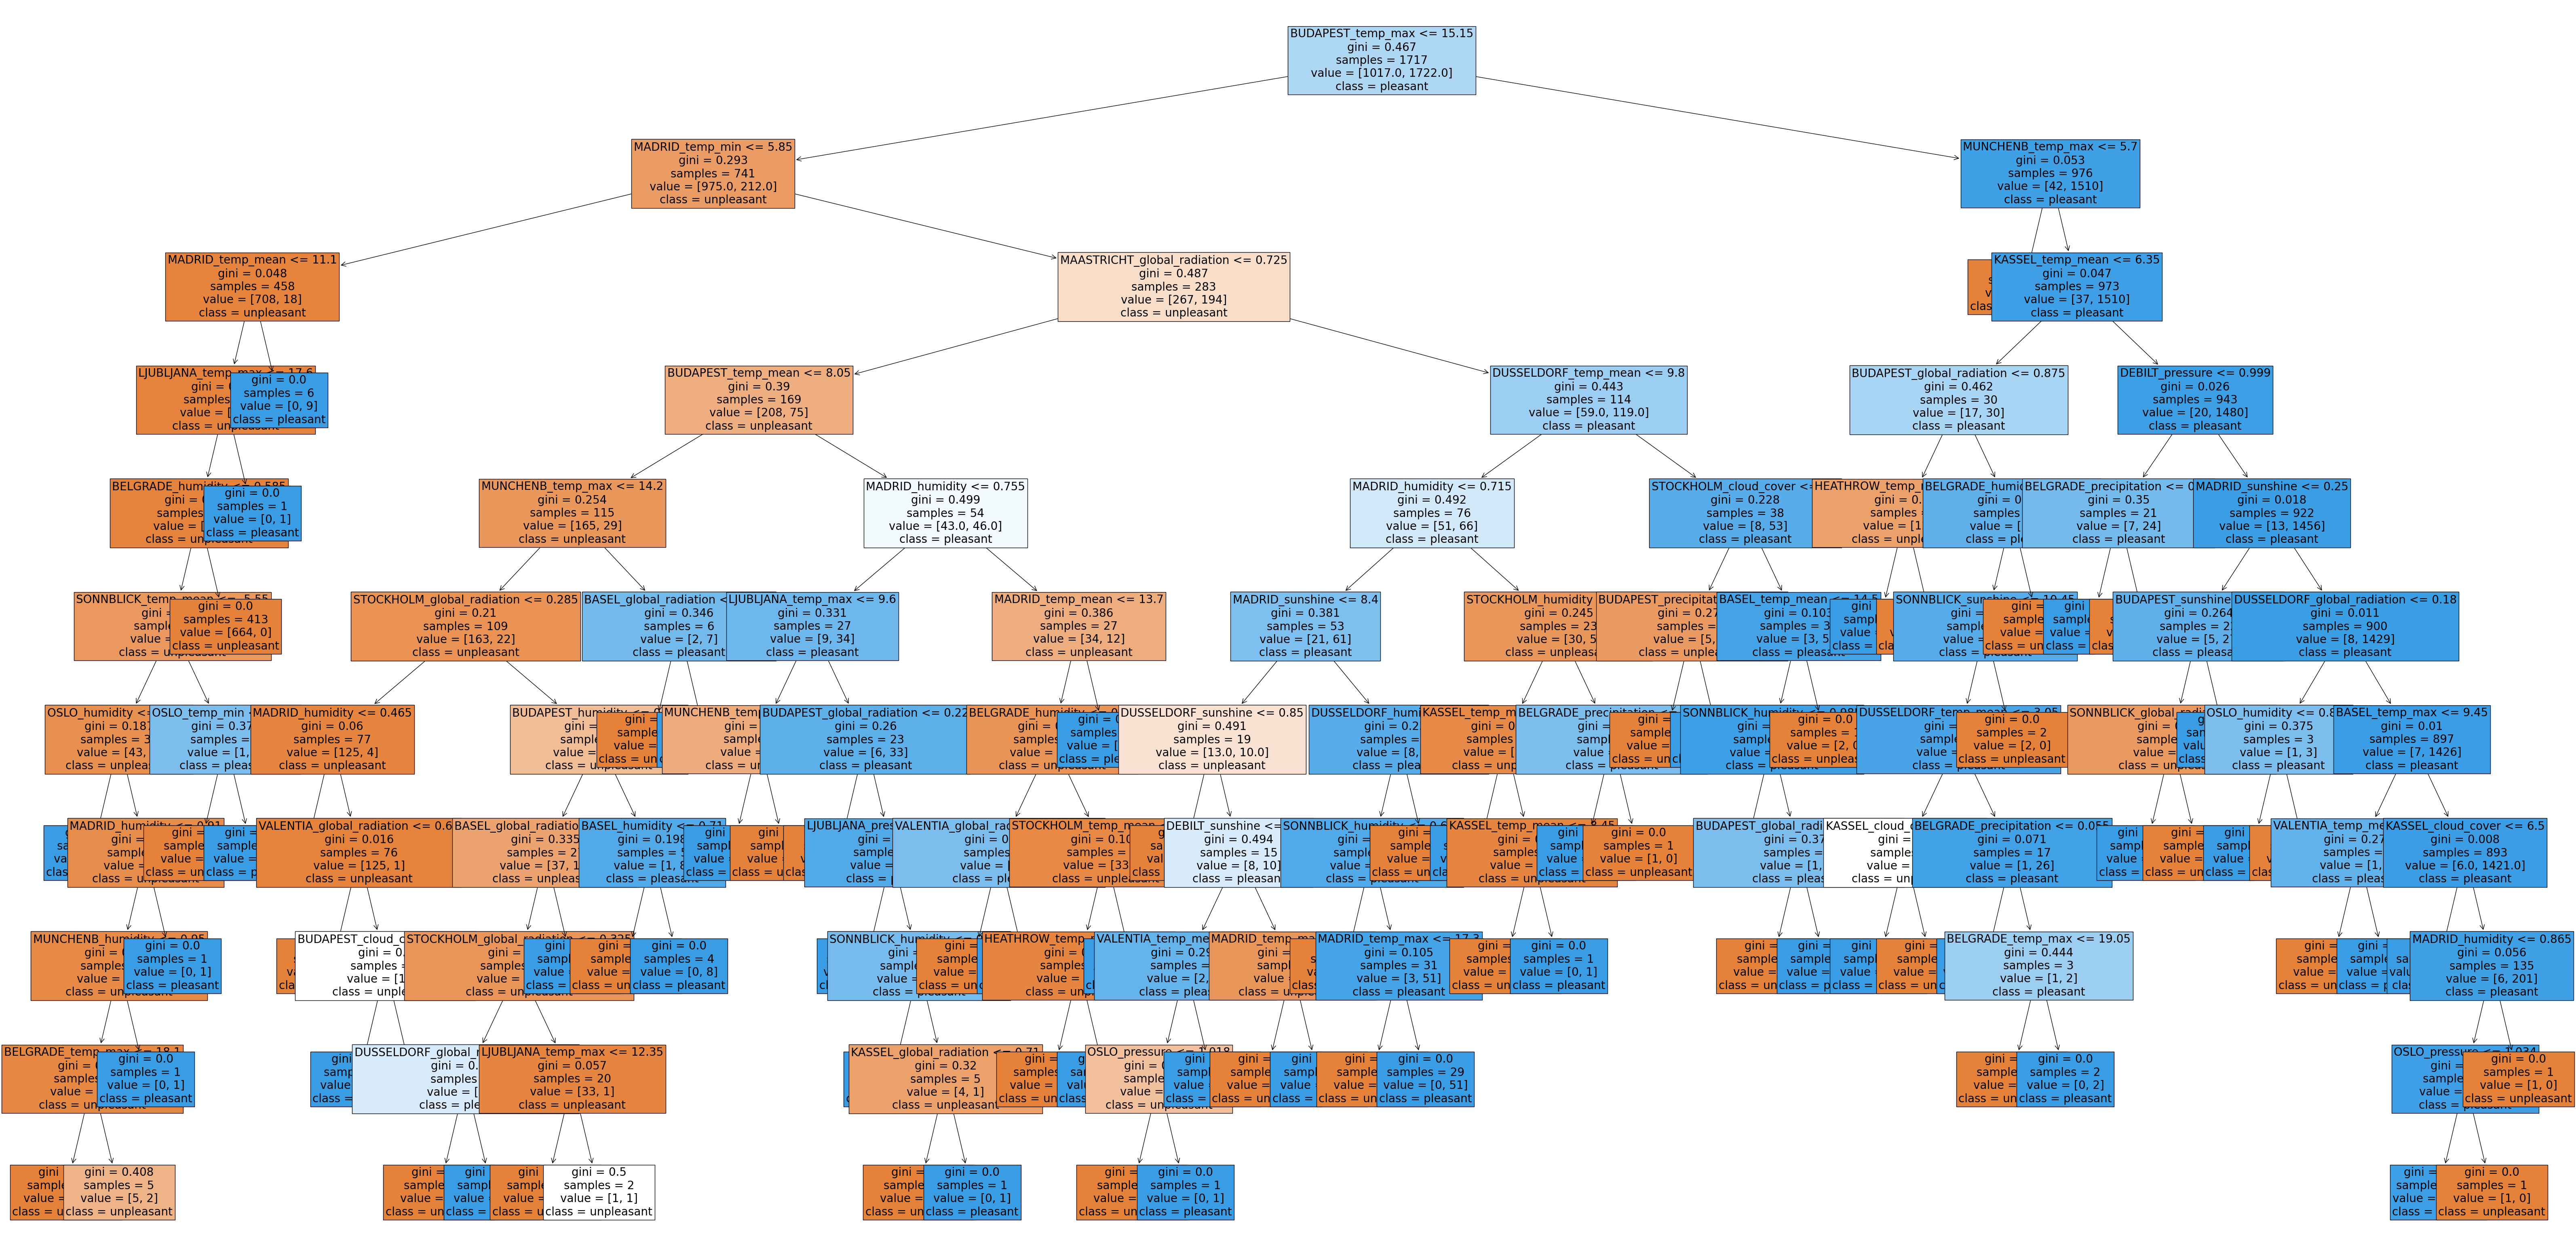

In [64]:
# Plotting the random forest for the 2000s

rf_2 = plt.figure(figsize=(80,40))
plot_tree(clf_2.estimators_[5], fontsize = 20, feature_names=cleaned_2000.columns, class_names=['unpleasant', 'pleasant'], filled=True)
plt.show();

In [65]:
rf_2.savefig(os.path.join(path, 'Visualizations', 'random_forest_2000s.png'),bbox_inches='tight')

# 4. Exploring the Feature Importances

In [67]:
# Retrieving the feature importances from the trained model

feature_importances_1 = clf_1.feature_importances_

print("Feature Importances:", feature_importances_1)
print(feature_importances_1.shape)

Feature Importances: [4.41194680e-04 1.14072916e-03 1.06520129e-03 1.75160455e-03
 5.78116356e-04 1.15930929e-03 1.80476823e-02 6.22109261e-03
 3.65083302e-02 7.14295904e-04 1.64117671e-03 1.95995868e-03
 1.20181501e-03 1.13855788e-03 1.03251621e-03 1.38862280e-02
 8.67613121e-03 1.50671391e-02 2.85750446e-04 0.00000000e+00
 0.00000000e+00 8.46889474e-04 1.00899396e-03 6.25941649e-04
 3.29528872e-02 1.00468548e-02 6.70439065e-02 5.31853359e-04
 8.87342101e-04 9.21927139e-04 2.90393885e-03 4.36003603e-04
 1.02267771e-03 7.40221801e-03 1.11356375e-03 5.70567164e-02
 4.59409804e-04 7.62682147e-04 1.10583613e-03 2.82043871e-03
 5.88202000e-04 5.76385828e-04 1.50865682e-02 1.34910285e-03
 2.52638806e-02 5.66172486e-04 1.50615633e-03 9.36689053e-04
 1.11136596e-02 6.08945181e-04 8.55273666e-04 1.01000036e-02
 1.50209513e-03 3.87451096e-02 3.63807757e-04 5.47065996e-04
 4.99156695e-04 2.90728487e-04 5.07201877e-04 3.43586210e-04
 6.88210499e-04 1.56302328e-03 6.75078765e-04 1.91141581e-04
 1.

In [68]:
# Reshaping the feature importances to (-1, 15, 9)

reshaped_importances_1 = feature_importances_1.reshape(-1, 15, 9)

In [69]:
# Checking the shape

print("Reshaped Importances Shape:", reshaped_importances_1.shape)

Reshaped Importances Shape: (1, 15, 9)


In [70]:
# Adding the values across the last dimension to get one observation for each weather station

collapsed_importances_1 = np.sum(reshaped_importances_1[0], axis=1)

In [71]:
# Checking both shapes

print("Collapsed Importances Shape:", collapsed_importances_1.shape)
print("Collapsed Importances:", collapsed_importances_1)

Collapsed Importances Shape: (15,)
Collapsed Importances: [0.06691326 0.04531782 0.11281122 0.07227624 0.04801251 0.0659341
 0.00547786 0.11149048 0.04865265 0.20271712 0.08959227 0.05695326
 0.0091049  0.06137165 0.00337466]


In [72]:
# Creating a list for the weather stations

stations = ['BASEL', 'BELGRADE', 'BUDAPEST', 'DEBILT', 'DUSSELDORF', 
            'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MADRID', 
            'MUNCHENB', 'OSLO', 'SONNBLICK', 'STOCKHOLM', 'VALENTIA']

In [73]:
# Creating a dataframe to associate weather stations with their importances

collapsed_importances_df_1 = pd.DataFrame({
    'Weather Station': stations,
    'Importance': collapsed_importances_1})

In [74]:
# Sorting by importance

collapsed_importances_df_1 = collapsed_importances_df_1.sort_values(by='Importance', ascending=False)

print("Collapsed Feature Importances:")
print(collapsed_importances_df_1)

Collapsed Feature Importances:
   Weather Station  Importance
9           MADRID    0.202717
2         BUDAPEST    0.112811
7        LJUBLJANA    0.111490
10        MUNCHENB    0.089592
3           DEBILT    0.072276
0            BASEL    0.066913
5         HEATHROW    0.065934
13       STOCKHOLM    0.061372
11            OSLO    0.056953
8       MAASTRICHT    0.048653
4       DUSSELDORF    0.048013
1         BELGRADE    0.045318
12       SONNBLICK    0.009105
6           KASSEL    0.005478
14        VALENTIA    0.003375


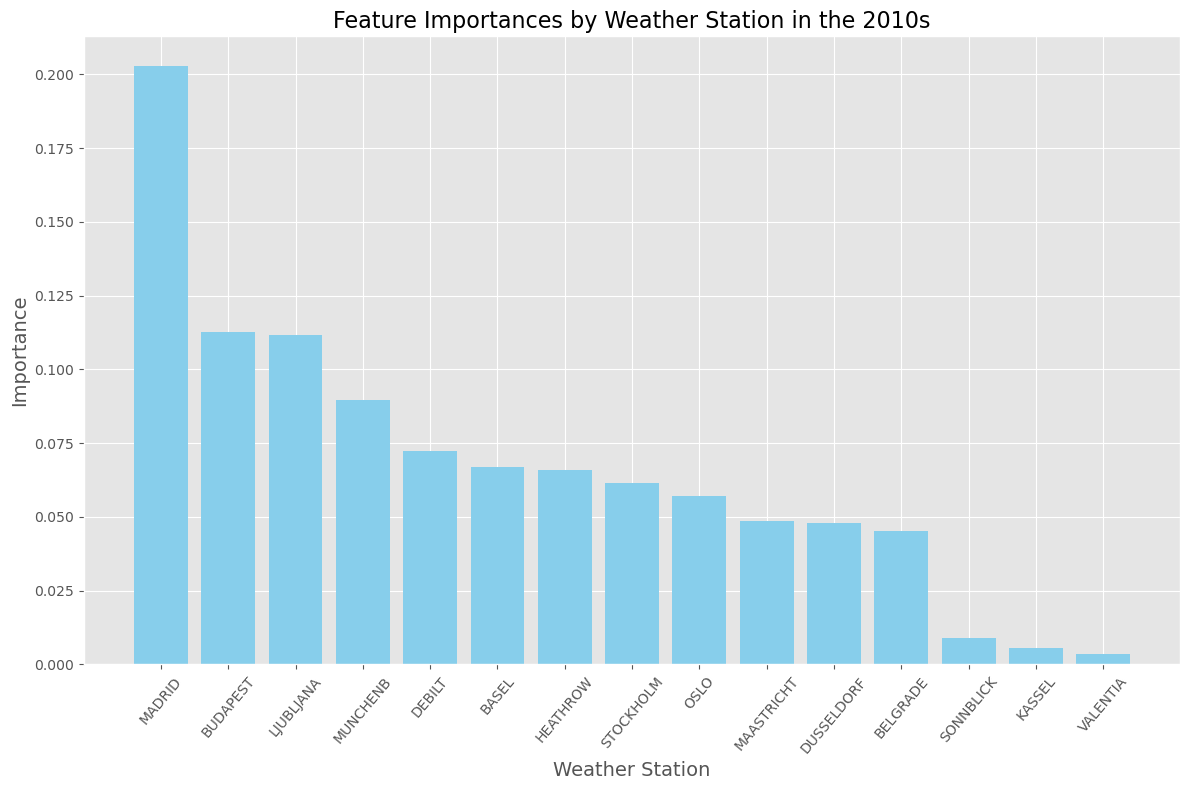

In [75]:
# Plotting the importances

plt.style.use('ggplot')
plt_1 = plt.figure(figsize=(12, 8))
plt.bar(collapsed_importances_df_1['Weather Station'], collapsed_importances_df_1['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Weather Station', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.title('Feature Importances by Weather Station in the 2010s', fontsize=16)
plt.tight_layout()

plt.show()

In [76]:
plt_1.savefig(os.path.join(path, 'Visualizations', 'feature_importances_2010s.png'),bbox_inches='tight')

##### 2000s Data

In [78]:
# Retrieving the feature importances from the trained model

feature_importances_2 = clf_2.feature_importances_

print("Feature Importances:", feature_importances_2)

Feature Importances: [0.00049124 0.00160752 0.00148577 0.00275167 0.00063966 0.00140539
 0.02858385 0.00189578 0.02289281 0.00125835 0.00427875 0.00129534
 0.00355826 0.00284783 0.00273752 0.0368673  0.01396088 0.01887135
 0.00054588 0.00165998 0.0015071  0.01123301 0.00116706 0.00237003
 0.06857562 0.02363241 0.0838595  0.00034533 0.00124797 0.0011055
 0.00586001 0.00072906 0.00122841 0.01312853 0.00170447 0.00357015
 0.00039526 0.00135518 0.00119339 0.00291624 0.00042571 0.00081691
 0.00384157 0.00115451 0.00834999 0.00030447 0.00123465 0.0009526
 0.00755777 0.00055101 0.00097955 0.00872862 0.00154715 0.01503194
 0.000535   0.00065098 0.00115476 0.00353616 0.00084598 0.00060099
 0.03578881 0.00255294 0.04928185 0.00055015 0.00151717 0.00174289
 0.00321868 0.00068274 0.00123768 0.02792275 0.00228219 0.05563686
 0.00046852 0.00104245 0.00073518 0.00203993 0.00056571 0.00079306
 0.00228929 0.00095081 0.00441648 0.00107271 0.00362363 0.00192953
 0.00810809 0.0021162  0.00342421 0.0935206

In [79]:
# Reshaping the feature importances to (-1, 15, 9)

reshaped_importances_2 = feature_importances_2.reshape(-1, 15, 9)

In [80]:
# Checking the shape

print("Reshaped Importances Shape:", reshaped_importances_2.shape)

Reshaped Importances Shape: (1, 15, 9)


In [81]:
# Adding the values across the last dimension to get one observation for each weather station

collapsed_importances_2 = np.sum(reshaped_importances_2[0], axis=1)

In [82]:
# Checking the shape

print("Collapsed Importances Shape:", collapsed_importances_2.shape)
print("Collapsed Importances:", collapsed_importances_2)

Collapsed Importances Shape: (15,)
Collapsed Importances: [0.06175368 0.08567557 0.19455059 0.02891942 0.02044876 0.03688775
 0.09494746 0.09479112 0.01330143 0.21604553 0.09099674 0.02050033
 0.01190826 0.01728883 0.01198452]


In [83]:
# Creating a dataframe to associate weather stations with their importances

collapsed_importances_df_2 = pd.DataFrame({
    'Weather Station': stations,
    'Importance': collapsed_importances_2})

In [84]:
# Sorting by importance

collapsed_importances_df_2 = collapsed_importances_df_2.sort_values(by='Importance', ascending=False)

print("Collapsed Feature Importances:")
print(collapsed_importances_df_2)

Collapsed Feature Importances:
   Weather Station  Importance
9           MADRID    0.216046
2         BUDAPEST    0.194551
6           KASSEL    0.094947
7        LJUBLJANA    0.094791
10        MUNCHENB    0.090997
1         BELGRADE    0.085676
0            BASEL    0.061754
5         HEATHROW    0.036888
3           DEBILT    0.028919
11            OSLO    0.020500
4       DUSSELDORF    0.020449
13       STOCKHOLM    0.017289
8       MAASTRICHT    0.013301
14        VALENTIA    0.011985
12       SONNBLICK    0.011908


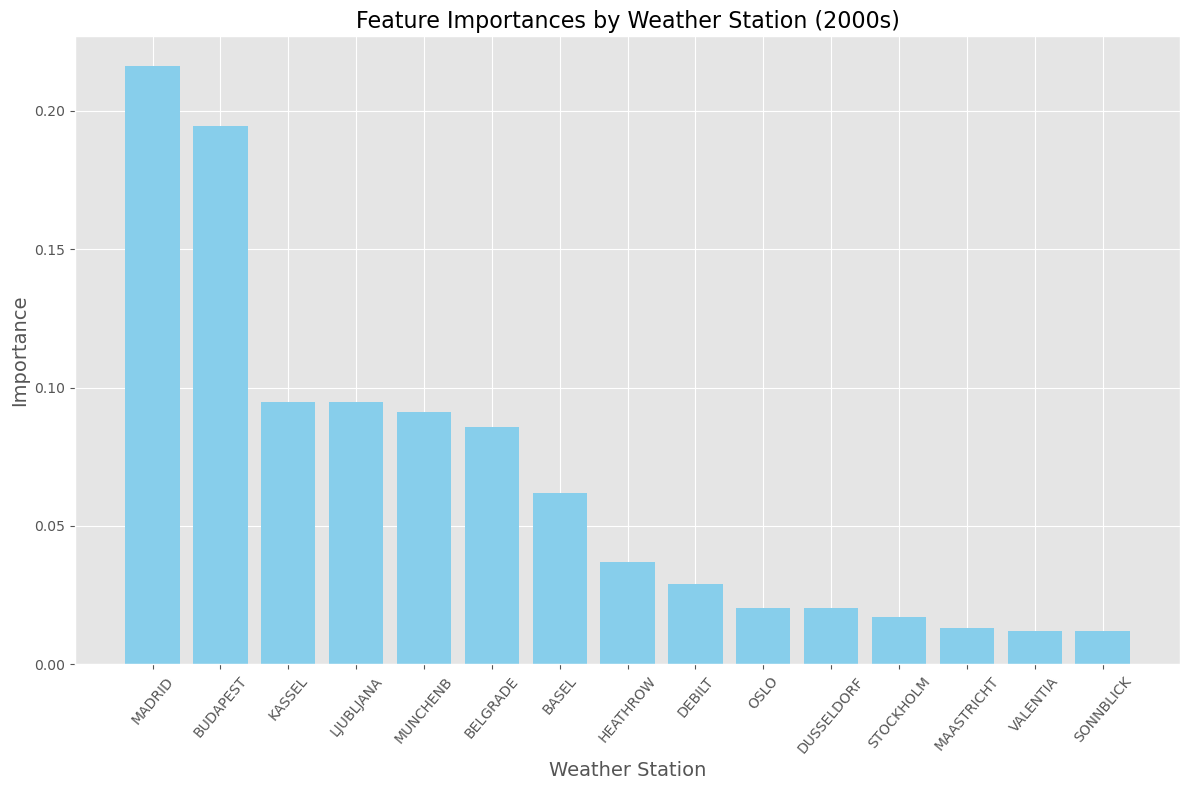

In [85]:
# Plotting the importances

plt.style.use('ggplot')
plt_2 = plt.figure(figsize=(12, 8))
plt.bar(collapsed_importances_df_2['Weather Station'], collapsed_importances_df_2['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Weather Station', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.title('Feature Importances by Weather Station (2000s)', fontsize=16)
plt.tight_layout()

plt.show()

In [86]:
plt_2.savefig(os.path.join(path, 'Visualizations', 'feature_importances_2000s.png'),bbox_inches='tight')

# 5. Top 3 Weather Stations and their Feature Importatances

### Madrid

In [89]:
# Filtering the weather dataset to only include Madrid

cw_madrid = unscaled[unscaled.columns[unscaled.columns.astype(str).str.startswith('MADRID')]]

In [90]:
cw_madrid.head()

,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max
0,6,0.92,1.0260,0.53,0.0,1.4,7.6,4.4,10.8
1,7,0.86,1.0254,0.46,0.0,0.9,9.8,7.4,12.2
2,5,0.90,1.0287,0.63,0.0,2.3,8.6,6.4,10.8
3,0,0.75,1.0281,1.16,0.0,8.7,10.3,4.5,16.1
4,2,0.64,1.0269,1.10,0.0,7.8,12.1,8.2,16.0


In [91]:
# Filtering the pleasant dataset to only include Madrid

pw_madrid = pleasant[pleasant.columns[pleasant.columns.astype(str).str.startswith('MADRID')]]

In [92]:
pw_madrid.head()

,MADRID_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [93]:
# Checking both shapes

print(cw_madrid.shape)
print(pw_madrid.shape)

(22950, 9)
(22950, 1)


In [94]:
# Create the matrices

y_3 = pw_madrid.max(axis=1)

In [95]:
# Checking the shape

print("Shape of y_3_combined:", y_3.shape)

Shape of y_3_combined: (22950,)


In [96]:
# Checking the unique values in y_combined

print("Unique values in y_3_combined:", y_3.unique())

Unique values in y_3_combined: [0 1]


In [97]:
# Checking to see that y has the correct shape

y_3 = y_3.to_numpy().reshape(-1)

In [98]:
# Checking the shape 

print(y_3.shape)

(22950,)


In [99]:
# Creating the X matrix

X_3 = cw_madrid.to_numpy()

In [100]:
# Checking the shapes of both matrices

print(X_3.shape)
print(y_3.shape)

(22950, 9)
(22950,)


In [101]:
# Splitting the data into training and testing sets

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, random_state=42)

# Checking the shapes

print(X_train_3.shape, y_train_3.shape)
print(X_test_3.shape, y_test_3.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


### Random Forest for Madrid

In [103]:
# Creating a Random Forest classifier

clf_3 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters

clf_3.fit(X_train_3, y_train_3)

RandomForestClassifier(max_depth=3)

In [104]:
# Performing the predictions on the test dataset

y_pred_3 = clf_3.predict(X_test_3)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test_3, y_pred_3))

Model Accuracy:  0.996514464970373


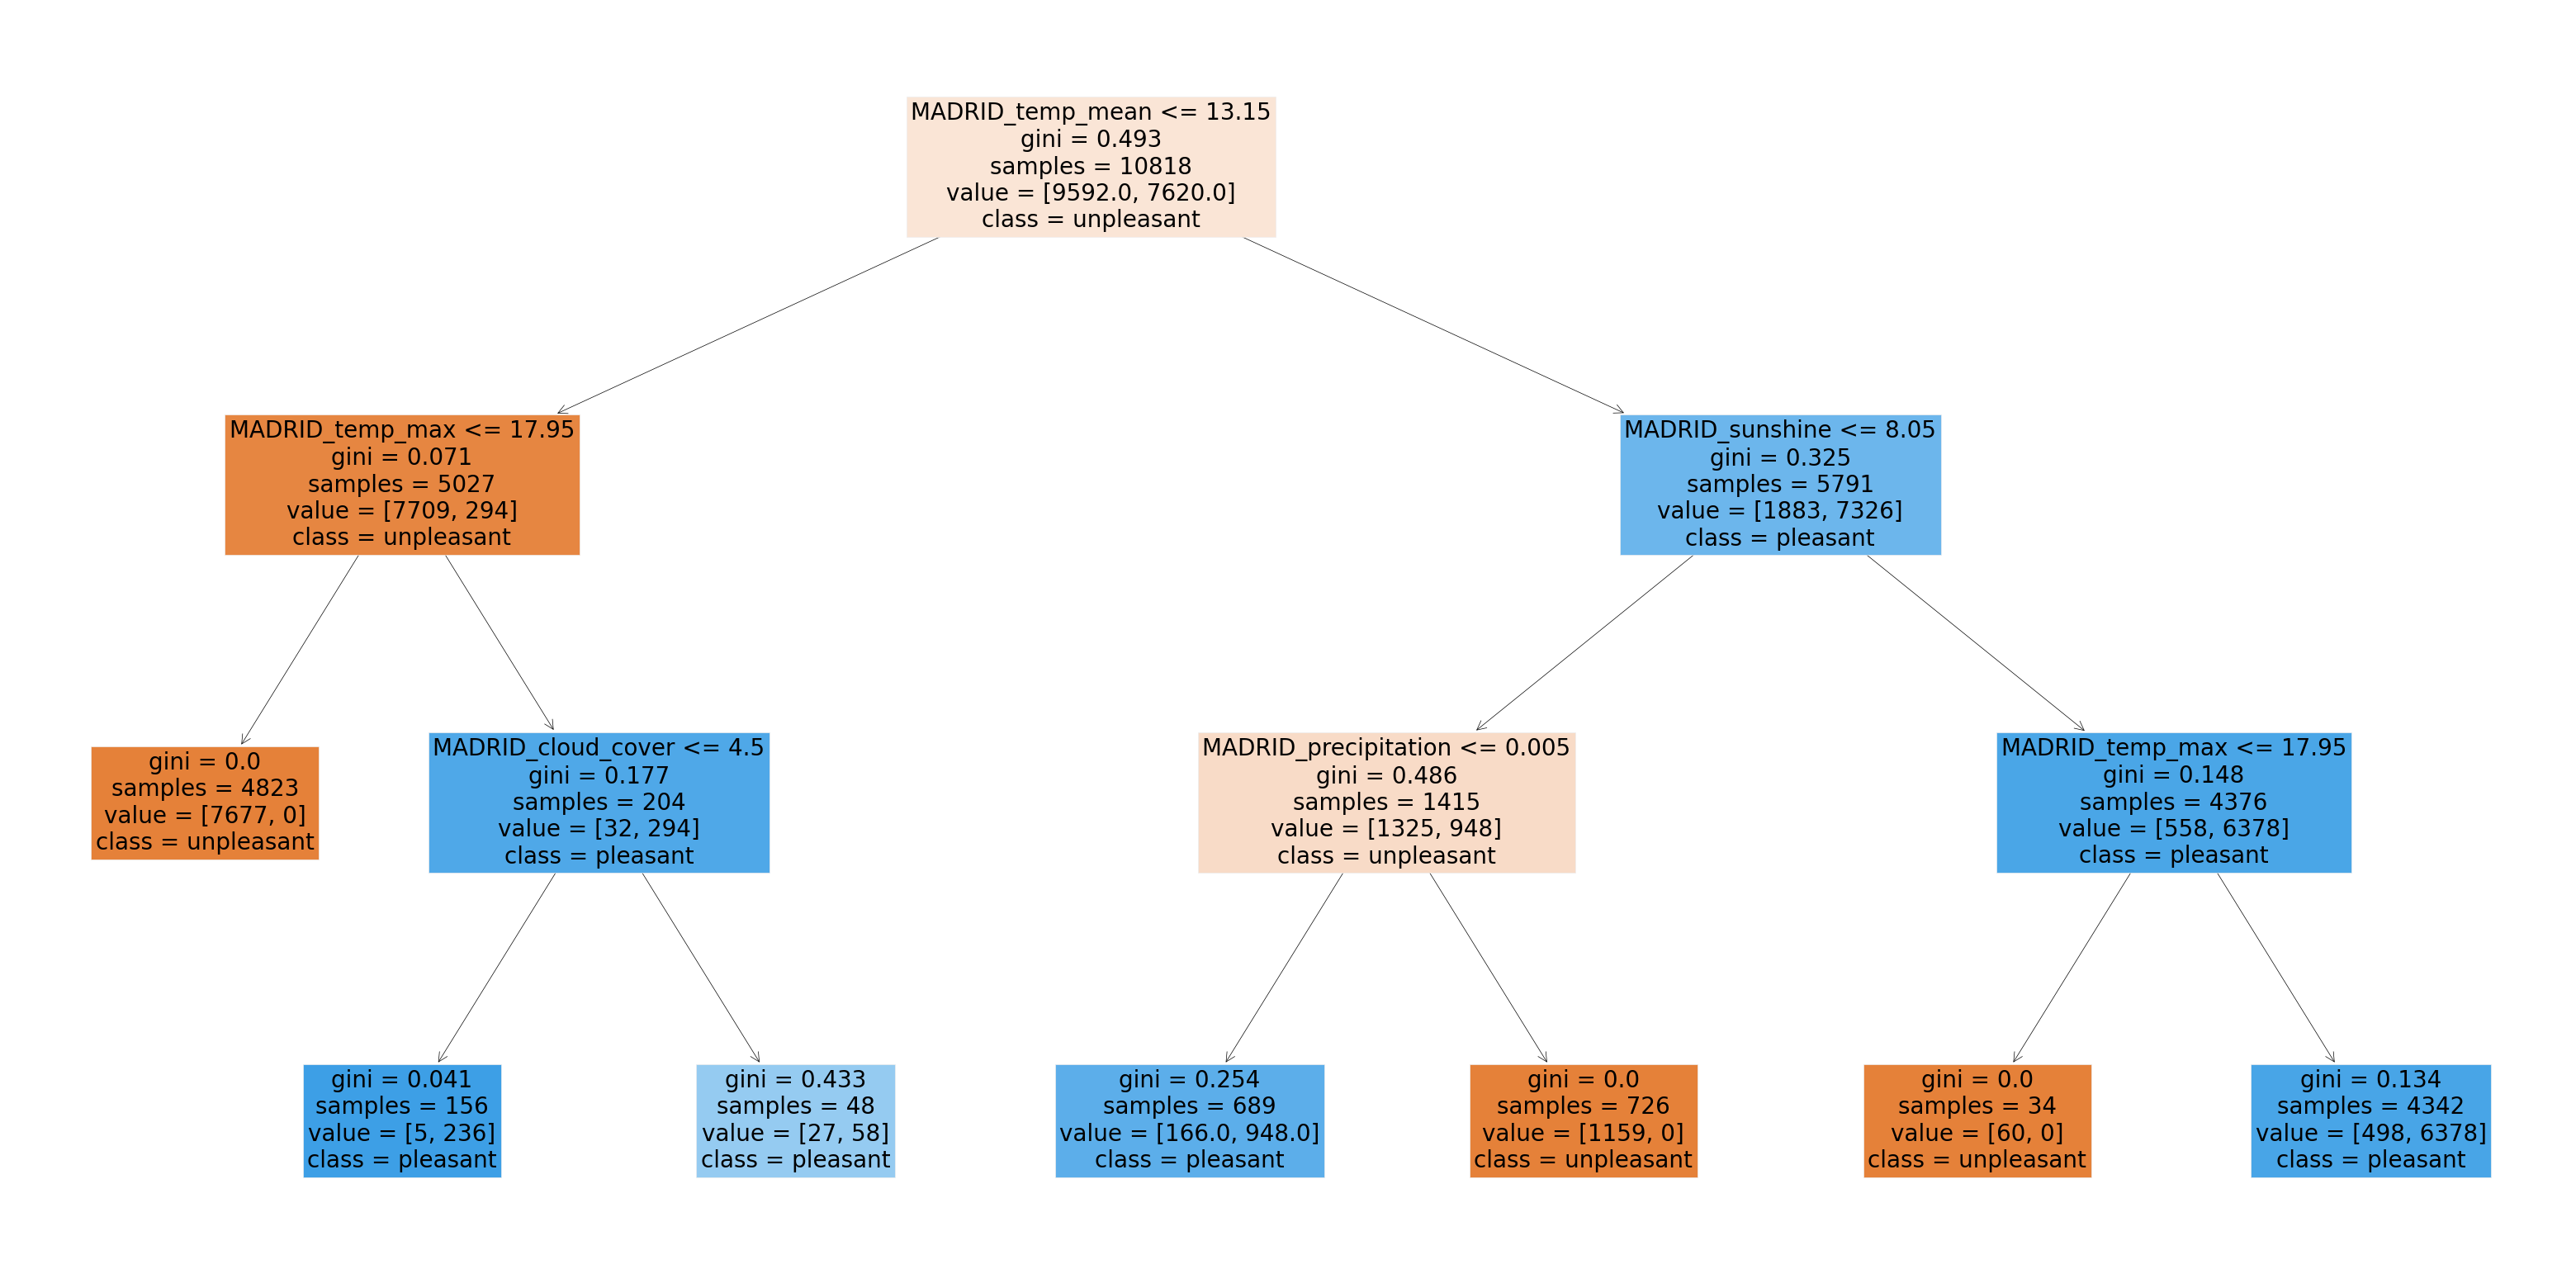

In [105]:
# Plotting the random forest for Madrid

rf_3 = plt.figure(figsize=(40,20))
plot_tree(clf_3.estimators_[5], fontsize = 20, feature_names=cw_madrid.columns, class_names=['unpleasant', 'pleasant'], filled=True)

plt.show();

In [106]:
rf_3.savefig(os.path.join(path, 'Visualizations', 'random_forest_madrid.png'),bbox_inches='tight')

### Feature Importances

In [108]:
# Retrieving the feature importances from the trained model

feature_importances_3 = clf_3.feature_importances_

print("Feature Importances:", feature_importances_3)
print(feature_importances_3.shape)

Feature Importances: [0.01806644 0.03579478 0.00095995 0.10762262 0.13241794 0.09107023
 0.17279381 0.06460541 0.37666882]
(9,)


In [109]:
# Creating a list for observation measurements

measurements = [
    'cloud_cover', 'humidity', 'pressure', 'global_radiation', 
    'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max']

In [110]:
# Creating a dataframe to associate observation measurements with their importances

importances_df_3 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_3})

In [111]:
# Sorting by importance

importances_df_3 = importances_df_3.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(importances_df_3)

Feature Importance:
        Measurement  Importance
8          temp_max    0.376669
6         temp_mean    0.172794
4     precipitation    0.132418
3  global_radiation    0.107623
5          sunshine    0.091070
7          temp_min    0.064605
1          humidity    0.035795
0       cloud_cover    0.018066
2          pressure    0.000960


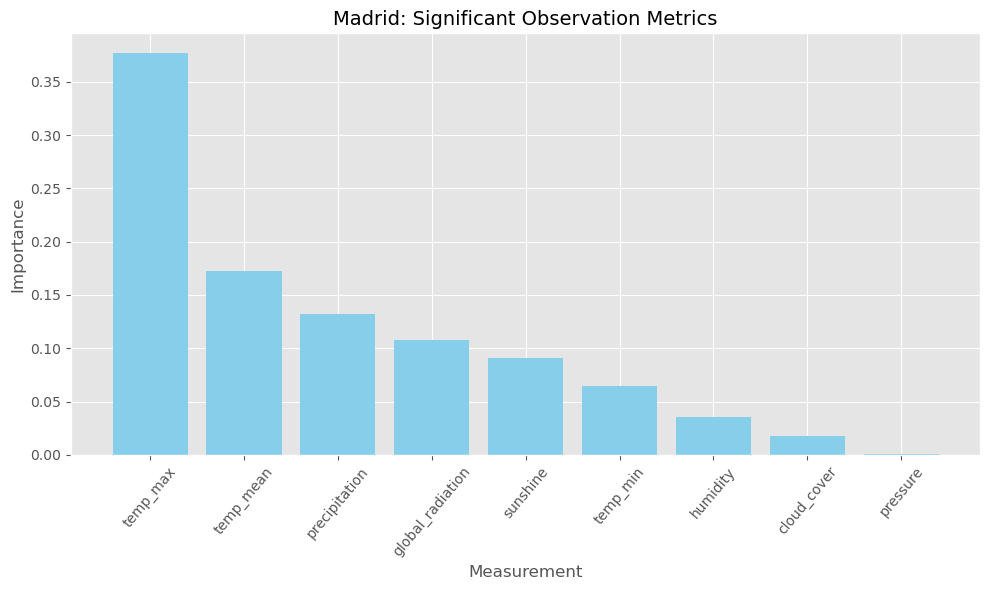

In [112]:
# Plotting the importances

plt.style.use('ggplot')
plt_3 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_3['Measurement'], importances_df_3['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Madrid: Significant Observation Metrics", fontsize=14)
plt.tight_layout()

plt.show()

##### Madrid: temp_max, temp_mean, precipiation.

### Budapest

In [115]:
# Filter weather dataset to only include Budapest

cw_budapest = unscaled[unscaled.columns[unscaled.columns.astype(str).str.startswith('BUDAPEST')]]

In [116]:
cw_budapest.head()

,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max
0,4,0.67,1.017,0.44,0.01,2.3,2.4,-0.4,5.1
1,4,0.67,1.017,0.18,0.31,0.0,2.3,1.4,3.1
2,4,0.67,1.017,0.30,0.00,0.6,2.7,1.7,5.3
3,4,0.67,1.017,0.19,0.00,0.0,2.0,0.4,4.4
4,4,0.67,1.017,0.19,0.00,0.0,2.5,1.1,5.3


In [117]:
# Filtering the pleasant dataset to only include Budapest

pw_budapest = pleasant[pleasant.columns[pleasant.columns.astype(str).str.startswith('BUDAPEST')]]

In [118]:
pw_budapest.head()

,BUDAPEST_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [119]:
# Checking both shapes

print(cw_budapest.shape)
print(pw_budapest.shape)

(22950, 9)
(22950, 1)


In [120]:
# Creating the matrices

y_4 = pw_budapest.max(axis=1)

In [121]:
# Checking the shape

print("Shape of y_4_combined:", y_4.shape)

Shape of y_4_combined: (22950,)


In [122]:
# Checking the unique values in y_combined

print("Unique values in y_4_combined:", y_4.unique())

Unique values in y_4_combined: [0 1]


In [123]:
# Checking to see that y has the correct shape

y_4 = y_4.to_numpy().reshape(-1)

# Check shape
print(y_4.shape)

(22950,)


In [124]:
# Creating the X matrix

X_4 = cw_budapest.to_numpy()

In [125]:
# Checking the shapes of both matrices

print(X_4.shape)
print(y_4.shape)

(22950, 9)
(22950,)


In [126]:
# Splitting the data into training and testing sets

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, random_state=127)

# Check shapes

print(X_train_4.shape, y_train_4.shape)
print(X_test_4.shape, y_test_4.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


### Random Forest for Budapest

In [128]:
# Creating a Random Forest classifier

clf_4 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters

clf_4.fit(X_train_4, y_train_4)

RandomForestClassifier(max_depth=3)

In [129]:
# Performing the predictions on the test dataset

y_pred_4 = clf_4.predict(X_test_4)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test_4, y_pred_4))

Model Accuracy:  0.9972115719762984


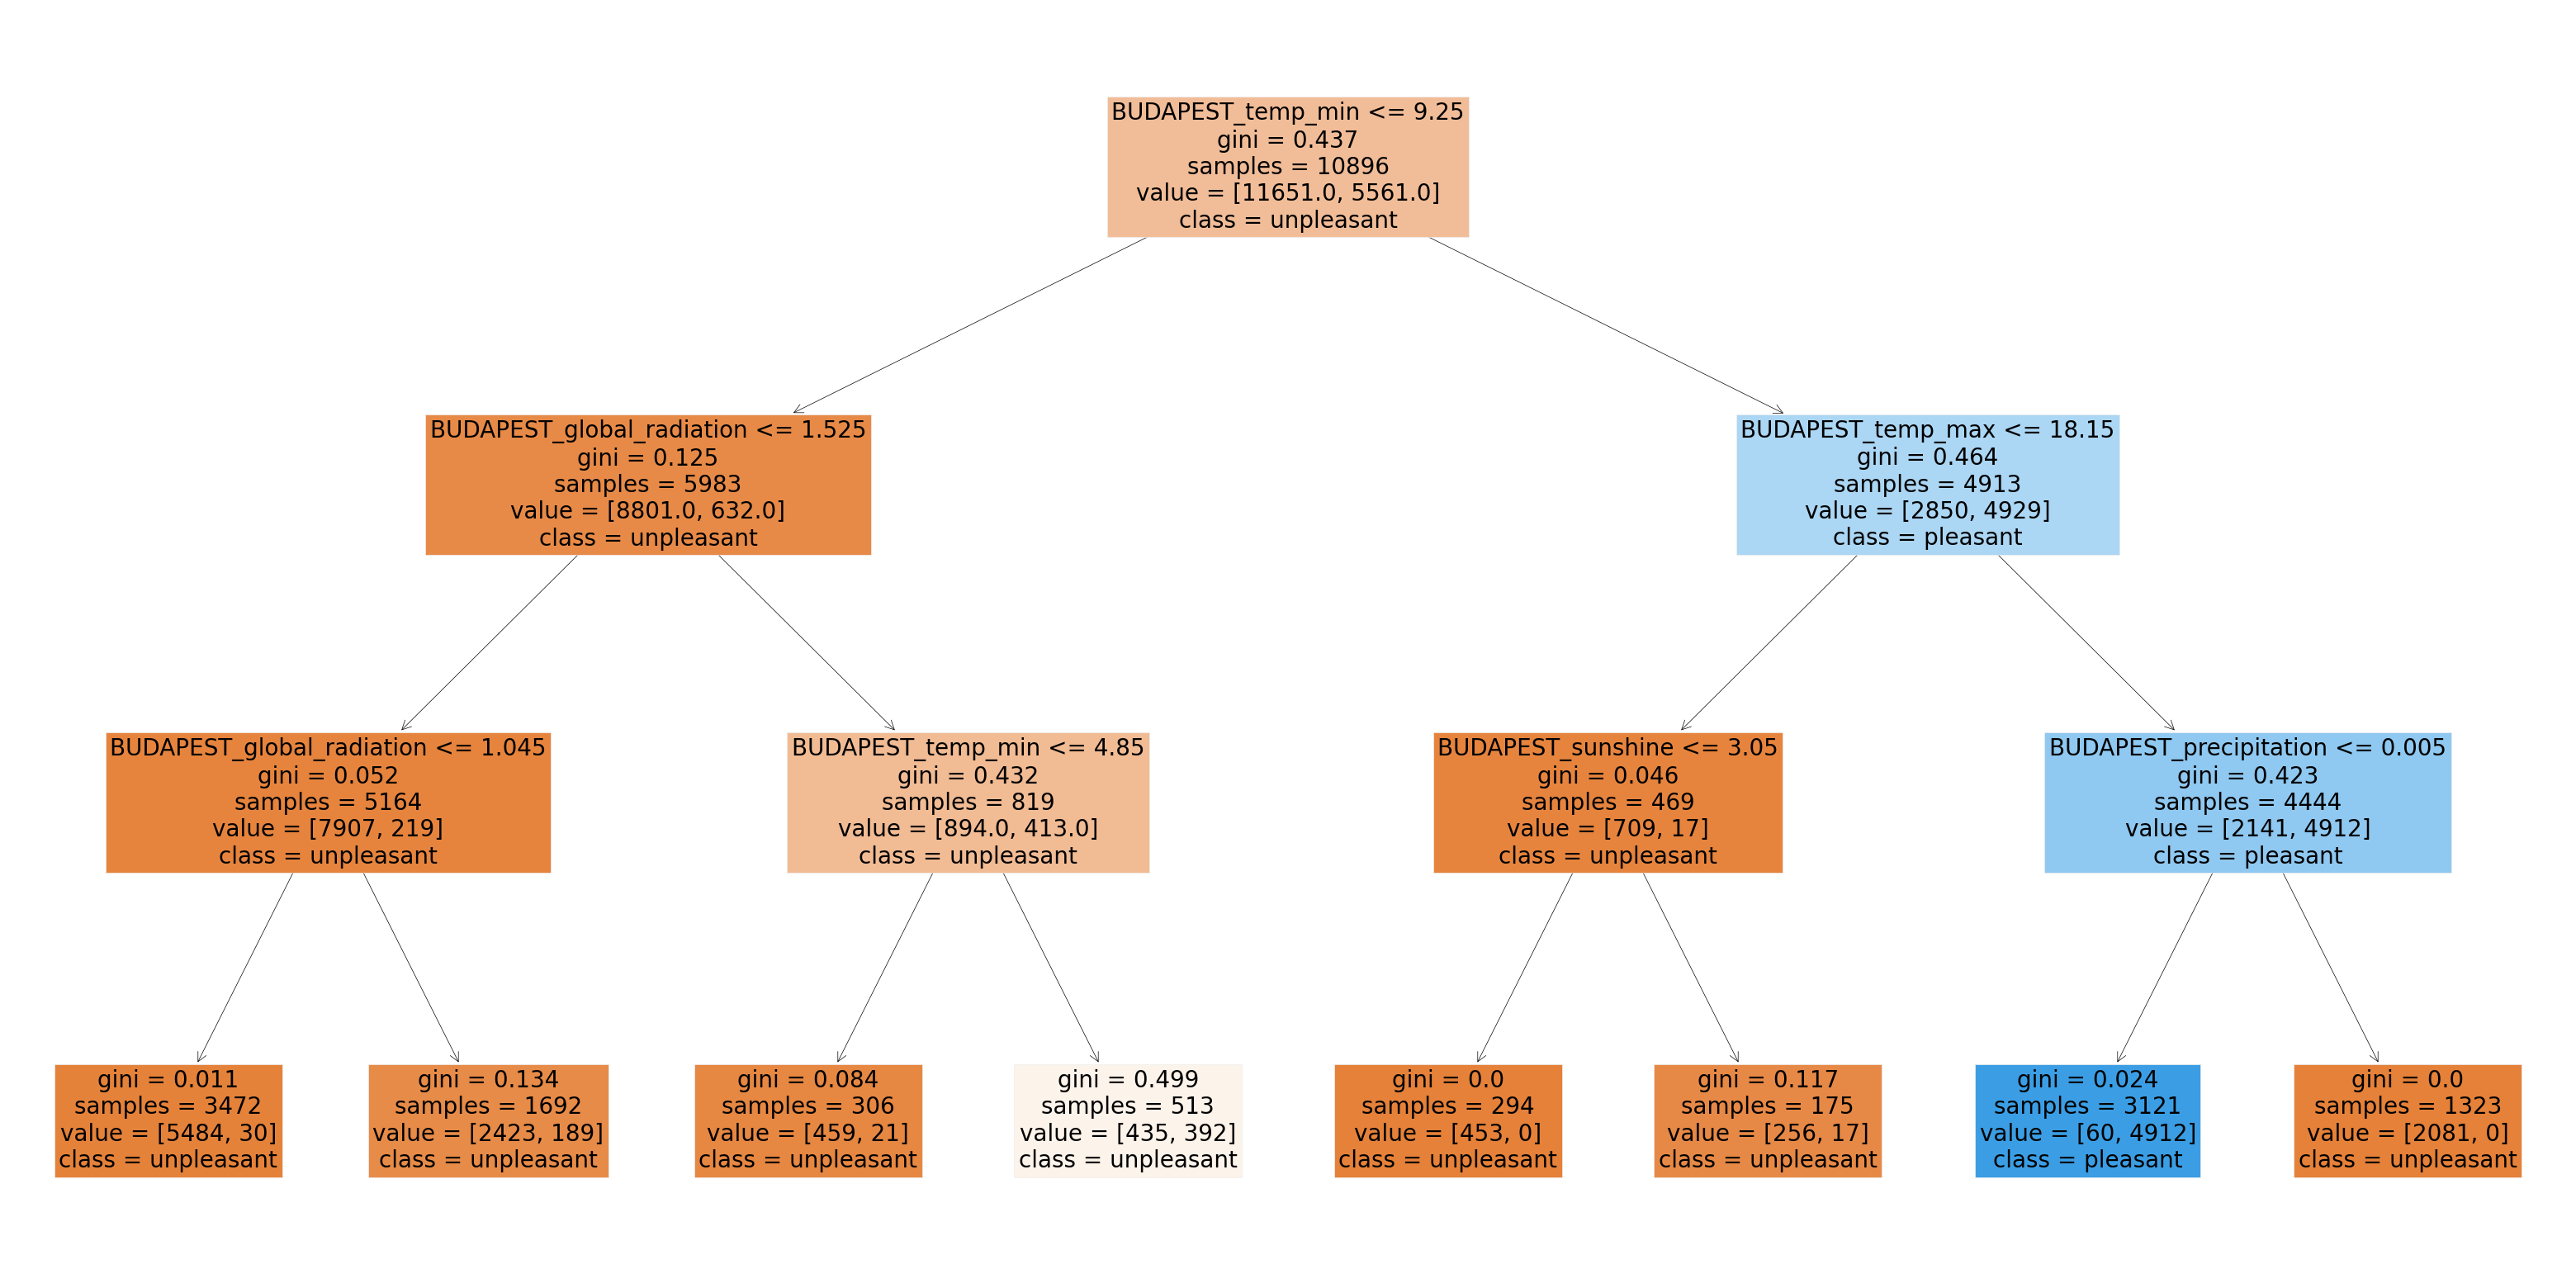

In [130]:
# Plotting the random forest for Budapest

rf_4 = plt.figure(figsize=(40,20))
plot_tree(clf_4.estimators_[5], fontsize = 20, feature_names=cw_budapest.columns, class_names=['unpleasant', 'pleasant'], filled=True)

plt.show();

In [131]:
rf_4.savefig(os.path.join(path, 'Visualizations', 'random_forest_budapest.png'),bbox_inches='tight')

##### Feature Importances

In [133]:
# Retrieving the feature importances from the trained model

feature_importances_4 = clf_4.feature_importances_

print("Feature Importances:", feature_importances_4)
print(feature_importances_4.shape)

Feature Importances: [0.01178131 0.00666182 0.00132693 0.08327283 0.21764376 0.07852769
 0.1826551  0.10415047 0.3139801 ]
(9,)


In [134]:
# Creating a dataframe to associate observation measurements with their importances

importances_df_4 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_4})

In [135]:
# Sorting by importance

importances_df_4 = importances_df_4.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(importances_df_4)

Feature Importance:
        Measurement  Importance
8          temp_max    0.313980
4     precipitation    0.217644
6         temp_mean    0.182655
7          temp_min    0.104150
3  global_radiation    0.083273
5          sunshine    0.078528
0       cloud_cover    0.011781
1          humidity    0.006662
2          pressure    0.001327


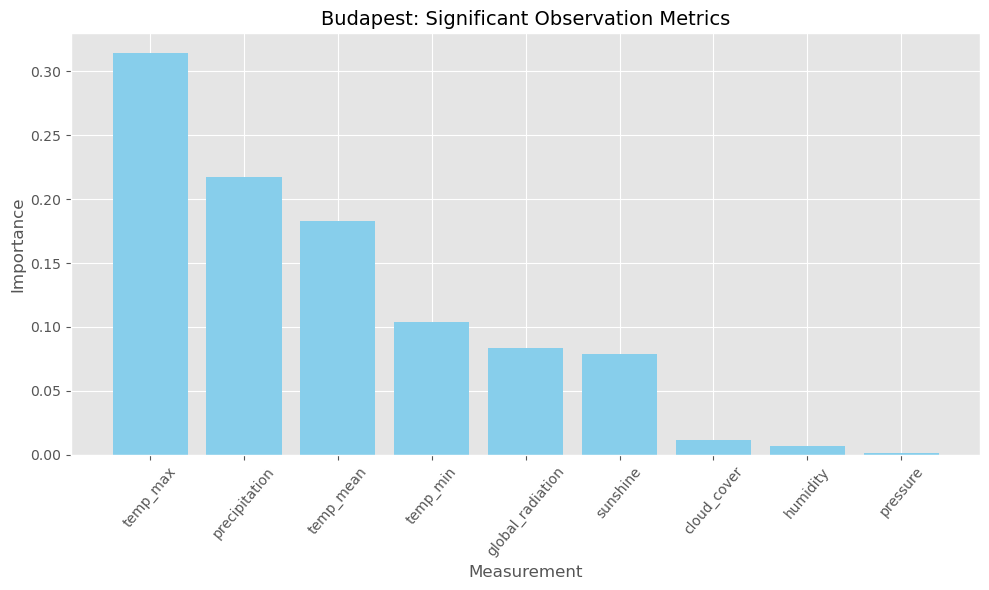

In [136]:
# Plotting the importances

plt.style.use('ggplot')
plt_4 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_4['Measurement'], importances_df_4['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Budapest: Significant Observation Metrics", fontsize=14)
plt.tight_layout()

plt.show()

##### Budapest: temp_max, precipitation, temp_mean.

### Munchenb

In [139]:
# Filter unscaled dataset to only include Munchenb

cw_munch = unscaled[unscaled.columns[unscaled.columns.astype(str).str.startswith('MUNCHENB')]]

In [140]:
cw_munch.head()

,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_pressure,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max
0,5,0.67,1.0304,0.20,0.10,0.0,6.9,1.1,10.4
1,6,0.72,1.0292,0.61,0.30,5.1,6.2,4.2,10.2
2,6,0.91,1.0320,0.20,0.30,0.0,5.8,4.0,8.0
3,6,0.90,1.0443,0.20,0.01,0.0,3.9,3.2,5.4
4,5,0.85,1.0430,0.65,0.96,5.6,1.8,-3.0,6.0


In [141]:
# Filter pleasant dataset to only include Munchenb

pw_munch = pleasant[pleasant.columns[pleasant.columns.astype(str).str.startswith('MUNCHENB')]]

In [142]:
pw_munch.head()

,MUNCHENB_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [143]:
# Checking both shapes

print(cw_munch.shape)
print(pw_munch.shape)

(22950, 9)
(22950, 1)


In [144]:
# Creating the matrices

y_5 = pw_munch.max(axis=1)

# Checking the shape

print("Shape of y_5_combined:", y_5.shape)

Shape of y_5_combined: (22950,)


In [145]:
# Checking the unique values in y_combined

print("Unique values in y_5_combined:", y_5.unique())

Unique values in y_5_combined: [0 1]


In [146]:
# Checking to see that y has the correct shape

y_5 = y_5.to_numpy().reshape(-1)

# Check shape

print(y_5.shape)

(22950,)


In [147]:
# Creating the X matrix

X_5 = cw_munch.to_numpy()

# Check shapes of the matrices

print(X_5.shape)
print(y_5.shape)

(22950, 9)
(22950,)


In [148]:
# Splitting data into training and testing sets

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y_5, random_state=127)

# Check shapes

print(X_train_5.shape, y_train_5.shape)
print(X_test_5.shape, y_test_5.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


### Random Forest for Munchenb

In [150]:
# Creating a Random Forest classifier

clf_5 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters

clf_5.fit(X_train_5, y_train_5)

RandomForestClassifier(max_depth=3)

In [151]:
# Performing the predictions on the test dataset

y_pred_5 = clf_5.predict(X_test_5)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test_5, y_pred_5))

Model Accuracy:  0.9975601254792611


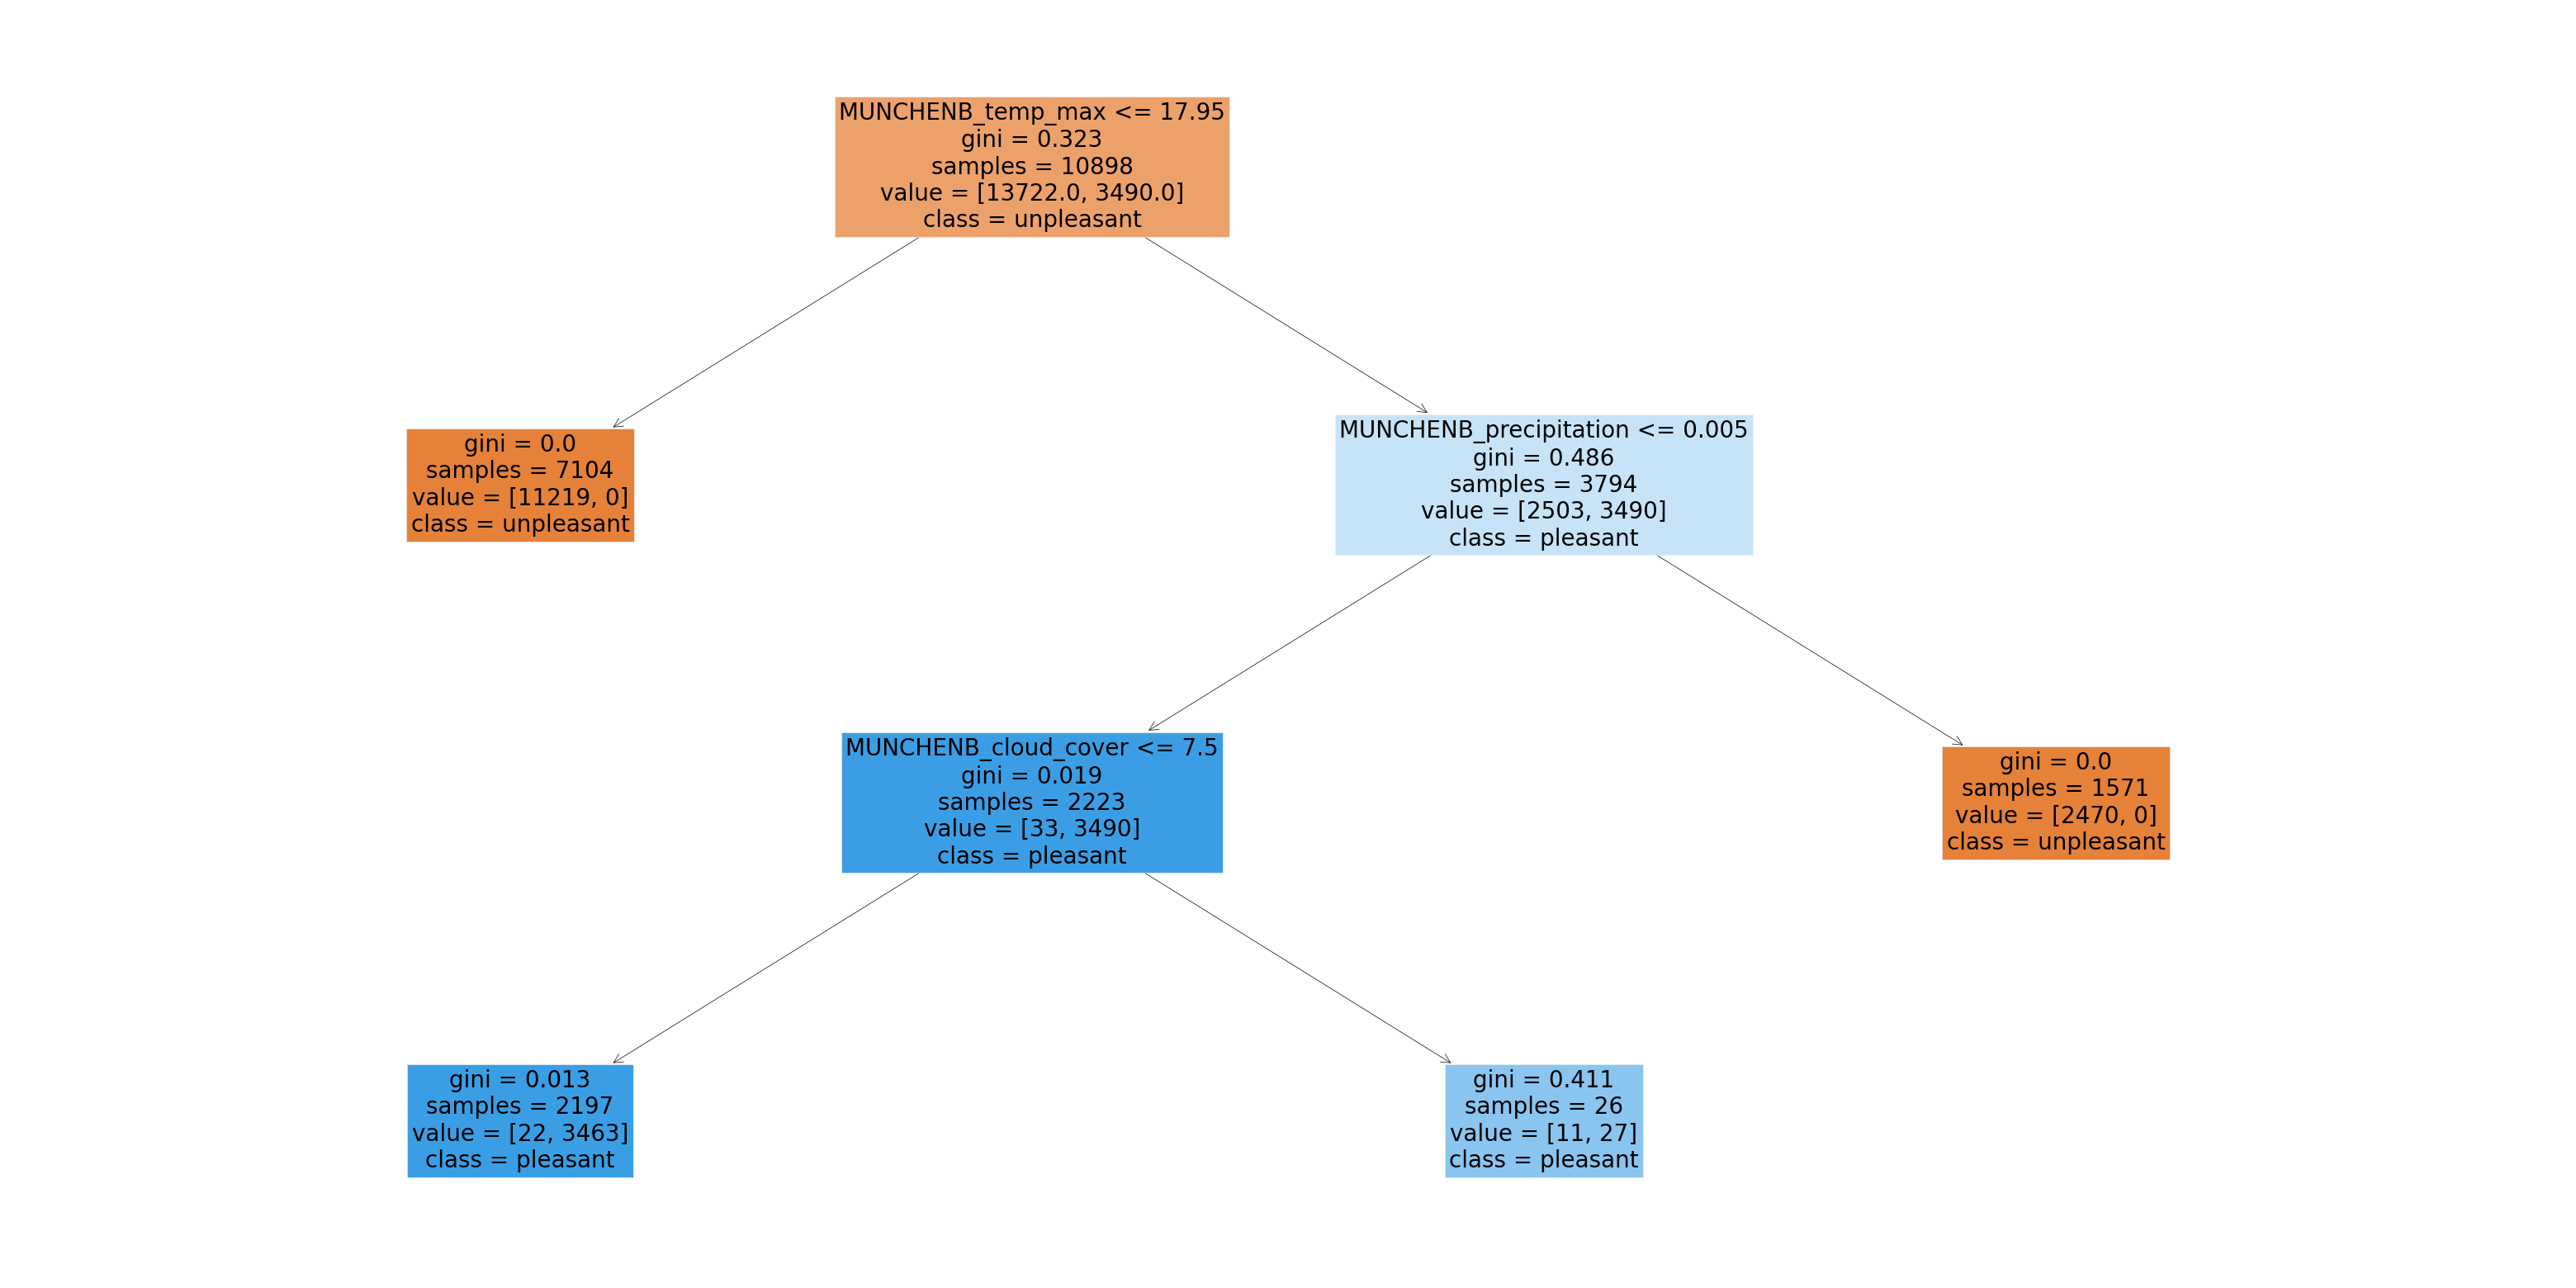

In [152]:
# Plotting the random forest for Munchenb

rf_5 = plt.figure(figsize=(40,20))
plot_tree(clf_5.estimators_[5], fontsize = 20, feature_names=cw_munch.columns, class_names=['unpleasant', 'pleasant'], filled=True)

plt.show();

In [153]:
rf_5.savefig(os.path.join(path, 'Visualizations', 'random_forest_munchenb.png'),bbox_inches='tight')

### Feature Importances

In [155]:
# Retrieving the feature importances from the trained model

feature_importances_5 = clf_5.feature_importances_

print("Feature Importances:", feature_importances_5)
print(feature_importances_5.shape)

Feature Importances: [0.05743756 0.00745694 0.00936047 0.06223921 0.21915786 0.13452458
 0.16747368 0.01899916 0.32335055]
(9,)


In [156]:
# Creating a dataframe to associate observation measurements with their importances

importances_df_5 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_5})

In [157]:
# Sorting by the importance

importances_df_5= importances_df_5.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(importances_df_5)

Feature Importance:
        Measurement  Importance
8          temp_max    0.323351
4     precipitation    0.219158
6         temp_mean    0.167474
5          sunshine    0.134525
3  global_radiation    0.062239
0       cloud_cover    0.057438
7          temp_min    0.018999
2          pressure    0.009360
1          humidity    0.007457


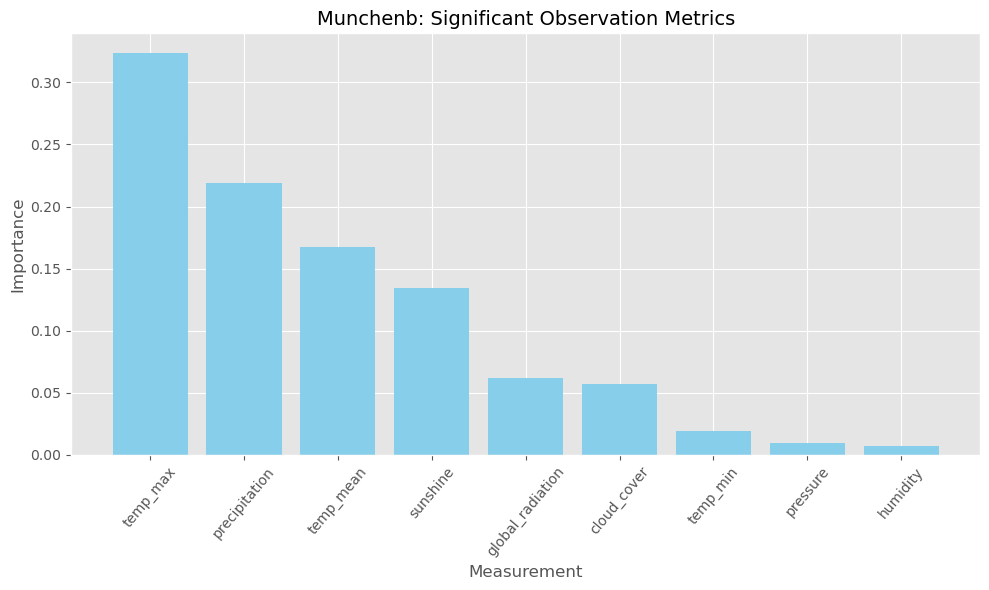

In [158]:
# Plotting the importances

plt.style.use('ggplot')
plt_5 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_5['Measurement'], importances_df_5['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Munchenb: Significant Observation Metrics", fontsize=14)
plt.tight_layout()

plt.show()

##### Munchenb: temp_max, precipitation, temp_mean.

### Debilt

In [297]:
# Filter unscaled dataset to only include DEBILT

cw_db = unscaled[unscaled.columns[unscaled.columns.astype(str).str.startswith('DEBILT')]]

In [299]:
cw_db.head()

,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max
0,7,0.85,1.0032,0.07,0.25,0.0,9.3,7.4,11.0
1,8,0.90,1.0056,0.14,0.06,0.1,7.7,6.4,8.3
2,6,0.92,1.0165,0.28,0.01,3.0,6.8,4.6,9.9
3,8,0.95,1.0265,0.08,0.09,0.0,6.7,3.6,10.1
4,6,0.90,1.0243,0.04,0.39,0.0,8.0,2.4,11.2


In [301]:
# Filter pleasant dataset to only include DEBILT

pw_db = pleasant[pleasant.columns[pleasant.columns.astype(str).str.startswith('DEBILT')]]

In [303]:
pw_db.head()

,DEBILT_pleasant_weather
0,0
1,0
2,0
3,0
4,0


In [305]:
# Checking both shapes

print(cw_db.shape)
print(pw_db.shape)

(22950, 9)
(22950, 1)


In [307]:
# Creating the matrices

y_6 = pw_db.max(axis=1)

# Checking the shape

print("Shape of y_6_combined:", y_6.shape)

Shape of y_6_combined: (22950,)


In [309]:
# Checking the unique values in y_combined

print("Unique values in y_6_combined:", y_6.unique())

Unique values in y_6_combined: [0 1]


In [311]:
# Checking to see that y has the correct shape

y_6 = y_6.to_numpy().reshape(-1)

# Check shape

print(y_6.shape)

(22950,)


In [313]:
# Creating the X matrix

X_6 = cw_db.to_numpy()

# Check shapes of the matrices

print(X_6.shape)
print(y_6.shape)

(22950, 9)
(22950,)


In [315]:
# Splitting data into training and testing sets

X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(X_6, y_6, random_state=127)

# Check shapes

print(X_train_6.shape, y_train_6.shape)
print(X_test_6.shape, y_test_6.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


### Random Forest for DEBILT

In [318]:
# Creating a Random Forest classifier

clf_6 = RandomForestClassifier(n_estimators = 100, max_depth=3)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters

clf_6.fit(X_train_6, y_train_6)

RandomForestClassifier(max_depth=3)

In [320]:
# Performing the predictions on the test dataset

y_pred_6 = clf_6.predict(X_test_6)
  
# Using the metrics module for accuracy calculation

print("Model Accuracy: ", metrics.accuracy_score(y_test_6, y_pred_6))

Model Accuracy:  0.9961659114674103


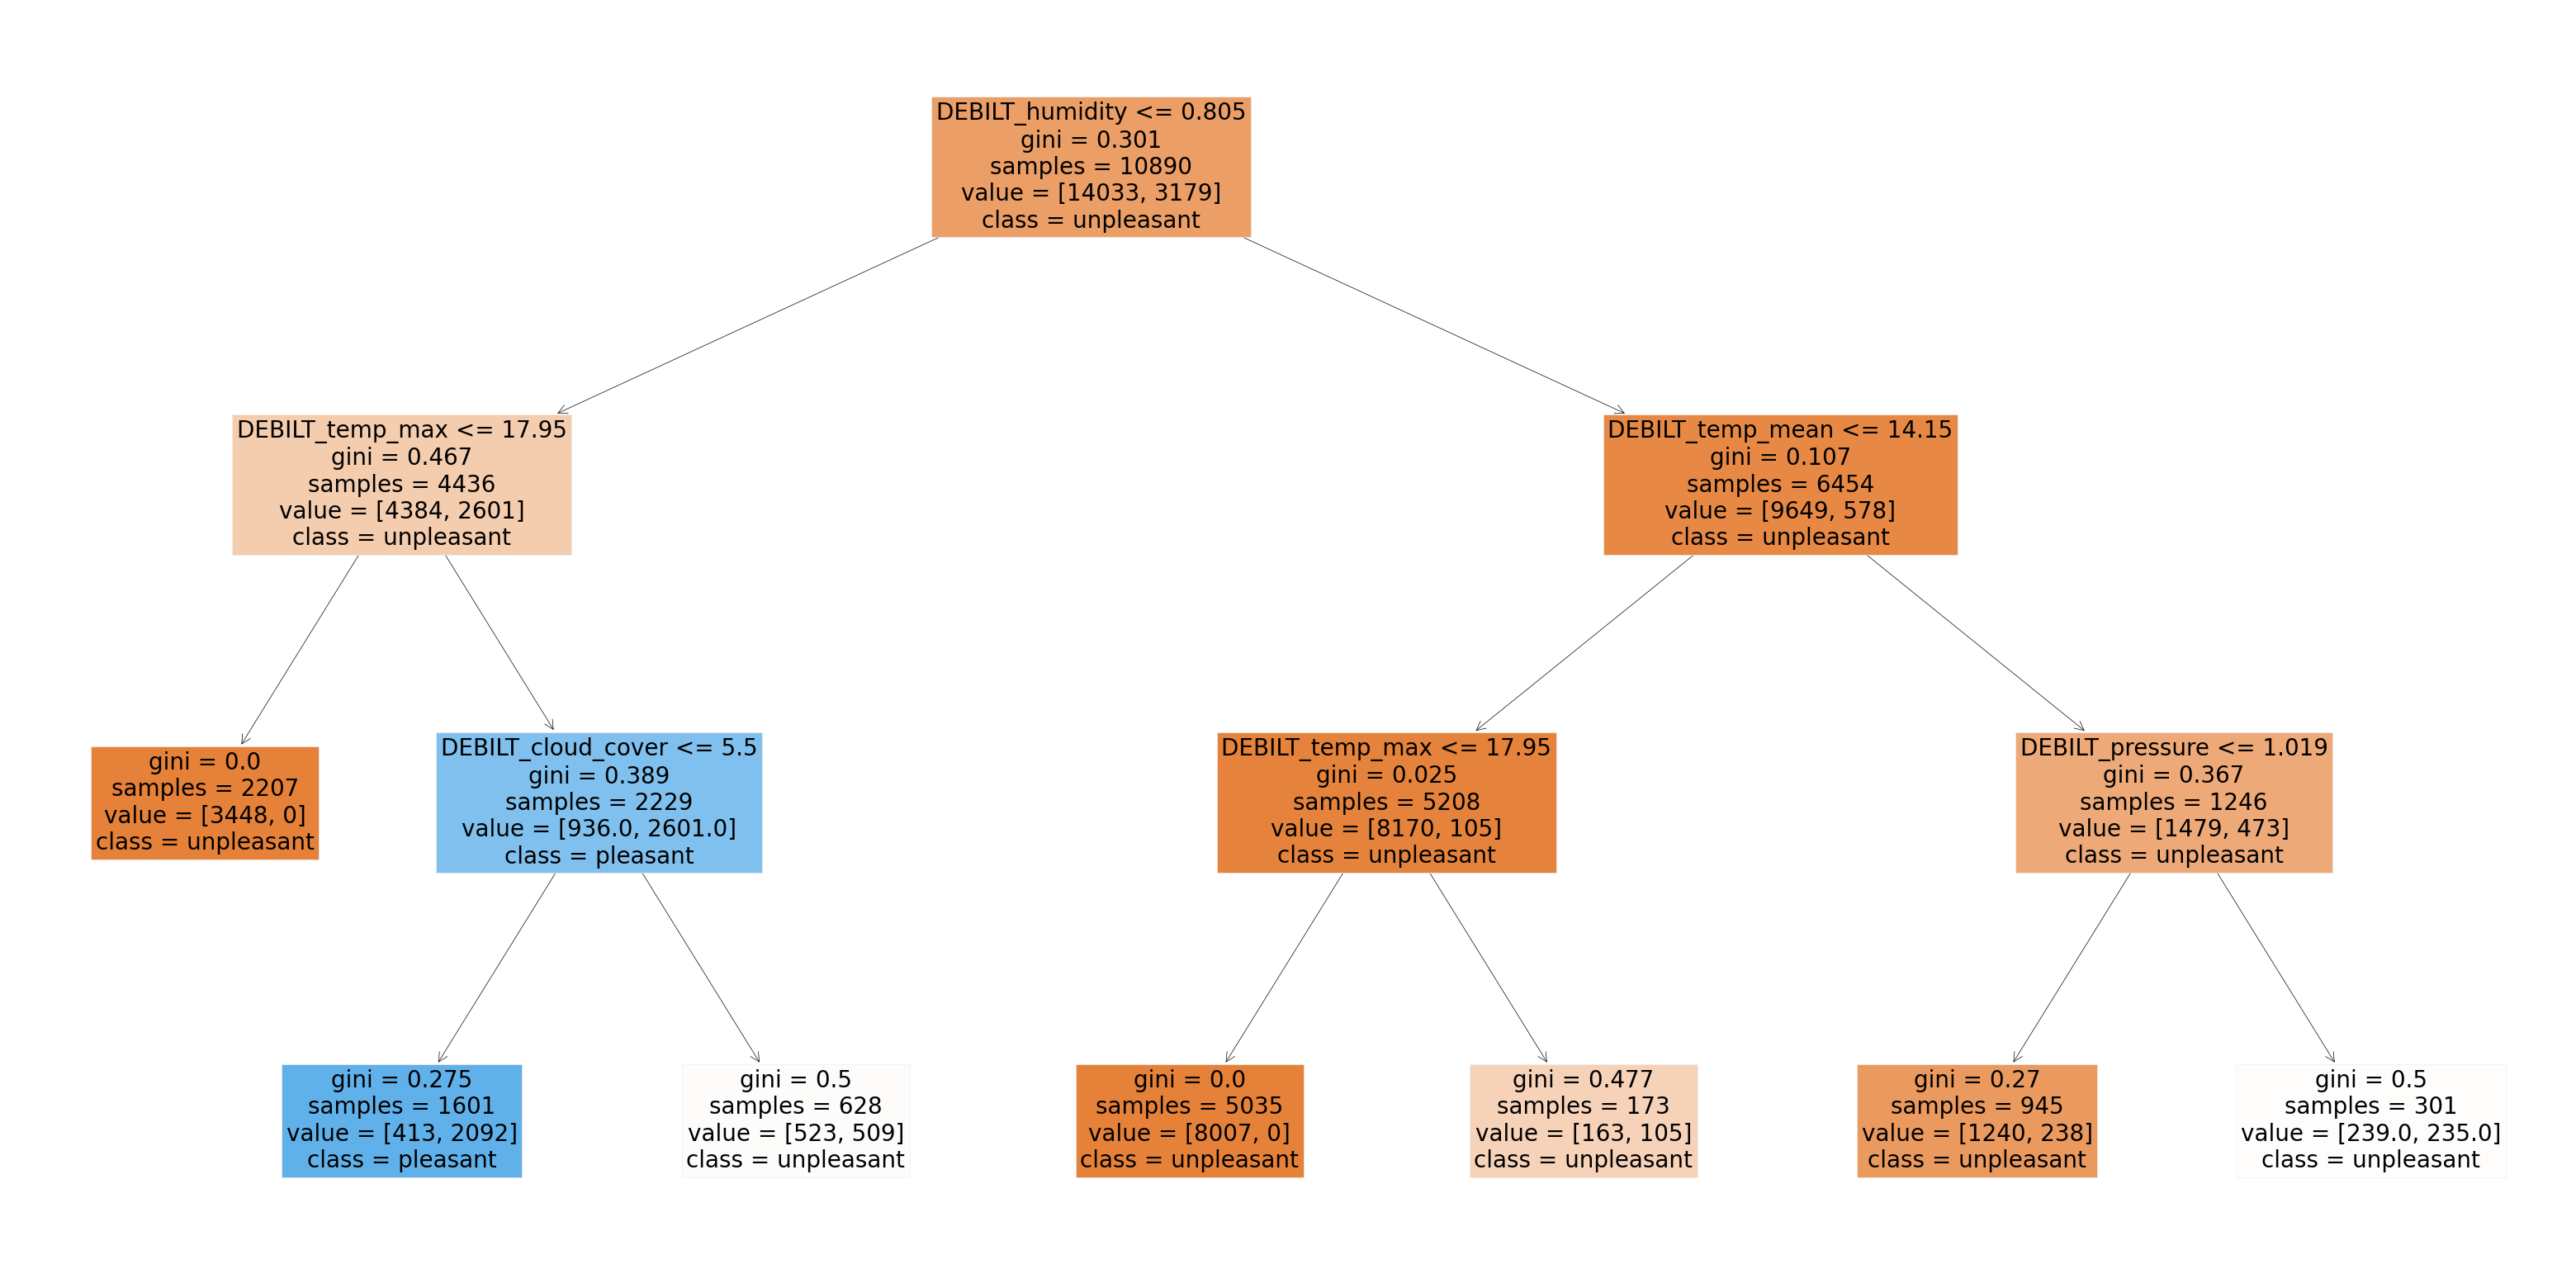

In [322]:
# Plotting the random forest for Munchenb

rf_6 = plt.figure(figsize=(40,20))
plot_tree(clf_6.estimators_[5], fontsize = 20, feature_names=cw_db.columns, class_names=['unpleasant', 'pleasant'], filled=True)

plt.show();

### Feature Importances

In [325]:
# Retrieving the feature importances from the trained model

feature_importances_6 = clf_6.feature_importances_

print("Feature Importances:", feature_importances_6)
print(feature_importances_6.shape)

Feature Importances: [0.03120704 0.01805387 0.00707185 0.1248617  0.23059397 0.05228758
 0.14365774 0.02661986 0.36564639]
(9,)


In [327]:
# Creating a dataframe to associate observation measurements with their importances

importances_df_6 = pd.DataFrame({
    'Measurement': measurements,
    'Importance': feature_importances_6})

In [329]:
# Sorting by the importance

importances_df_6= importances_df_6.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(importances_df_6)

Feature Importance:
        Measurement  Importance
8          temp_max    0.365646
4     precipitation    0.230594
6         temp_mean    0.143658
3  global_radiation    0.124862
5          sunshine    0.052288
0       cloud_cover    0.031207
7          temp_min    0.026620
1          humidity    0.018054
2          pressure    0.007072


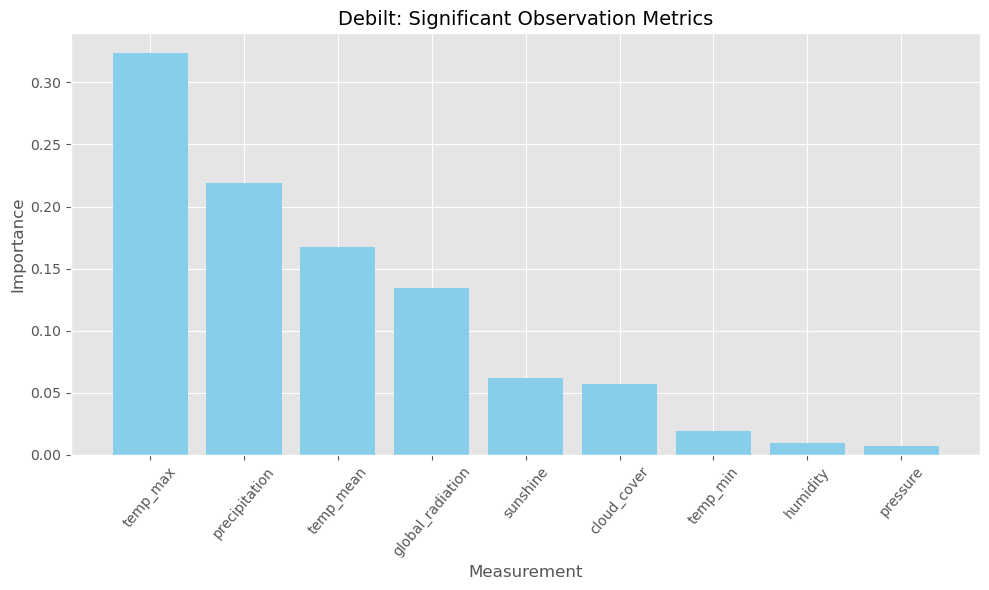

In [331]:
# Plotting the importances

plt.style.use('ggplot')
plt_6 = plt.figure(figsize=(10, 6))
plt.bar(importances_df_6['Measurement'], importances_df_5['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Measurement', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title("Debilt: Significant Observation Metrics", fontsize=14)
plt.tight_layout()

plt.show()

##### Debilt: temp_max, precipiation, and temp_mean.